# JAX-3-27 — вязкое уравнение Бюргерса 2D/3D

Итоговый ноутбук курсовой работы по численному решению вязкого уравнения Бюргерса с использованием JAX.

В работе реализованы две многомерные постановки вязкого векторного уравнения Бюргерса:

**2D:**

$$
\frac{\partial \mathbf{u}}{\partial t}+(\mathbf{u}\cdot\nabla)\mathbf{u}=\nu\Delta\mathbf{u},
\qquad \mathbf{u}=(u,v),
\qquad \Omega=[0,2\pi]\times[0,2\pi].
$$

**3D:**

$$
\frac{\partial \mathbf{u}}{\partial t}+(\mathbf{u}\cdot\nabla)\mathbf{u}=\nu\Delta\mathbf{u},
\qquad \mathbf{u}=(u,v,w),
\qquad \Omega=[0,2\pi]^3.
$$

В ноутбуке реализованы:

1. Спектральный метод Фурье на периодической сетке для 2D и 3D.
2. 2/3 de-aliasing для нелинейной конвекции.
3. Strang splitting: половина диффузии → RK4-конвекция → половина диффузии.
4. Спектральная стабилизация для режима малых вязкостей.
5. Аналитическая валидация через 1D-редукцию и преобразование Коула — Хопфа.
6. Основные 2D- и 3D-примеры при малой вязкости.
7. Сохранение и отображение результатов в `.npz`, `.csv`, `.json`, `.png`.

Все ключевые результаты после расчёта отображаются прямо в ноутбуке: таблицы ошибок, история расчёта, параметры запуска, графики полей и диагностика.

Валидационный режим запускается без дополнительной стабилизации: `eps4=0`, `filter_strength=0`. Это позволяет сравнивать численное решение с аналитическим решением исходного уравнения.


In [1]:
# ============================================================
# 1. Imports and global settings
# ============================================================

# Зависимости для локального запуска:
# pip install "jax[cpu]" numpy pandas matplotlib
#
# В Google Colab JAX обычно уже установлен. Установка CUDA-версии JAX
# оставлена вне ноутбука, чтобы код одинаково запускался на CPU и GPU-окружениях.

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from dataclasses import dataclass, asdict
from pathlib import Path
import json
import math
import time
from typing import Callable, Dict, List, Optional, Tuple

import jax
jax.config.update("jax_enable_x64", True)  # важно: до import jax.numpy

import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, JSON as IPythonJSON
except Exception:  # fallback for plain Python script execution
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

    class IPythonJSON:  # minimal fallback
        def __init__(self, data):
            self.data = data
        def __repr__(self):
            return json.dumps(self.data, ensure_ascii=False, indent=2)

REAL = jnp.float64
COMPLEX = jnp.complex128

BASE_DIR = Path("burgers2d3d_results")
IMG_DIR = BASE_DIR / "images"
DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"

for folder in (IMG_DIR, DATA_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())
print("Backend:", jax.default_backend())
print("Results directory:", BASE_DIR.resolve())

JAX version: 0.7.2
Devices: [CpuDevice(id=0)]
Backend: cpu
Results directory: /content/burgers2d3d_results


## 2. Конфигурация расчёта

`SimulationConfig` хранит параметры одного 2D-запуска: размер сетки, физическую вязкость, конечное время, CFL-число и параметры численной стабилизации.

Для 3D ниже задана отдельная структура `SimulationConfig3D`, потому что там появляется третье пространственное направление `z`.

Стабилизация (`eps4`, `filter_strength`) отделена от физической вязкости `nu`. В аналитической валидации она отключается. В сценариях малой вязкости она используется как численная регуляризация для подавления высокочастотных осцилляций около резких фронтов.


In [2]:
# ============================================================
# 2. Configuration and grid
# ============================================================

@dataclass(frozen=True)
class SimulationConfig:
    nx: int = 128
    ny: int = 128
    lx: float = 2.0 * math.pi
    ly: float = 2.0 * math.pi
    nu: float = 1e-2
    t_final: float = 0.3
    cfl: float = 0.20
    eps4: float = 0.0                 # artificial hyperviscosity coefficient
    filter_strength: float = 0.0      # exponential spectral filter strength
    filter_order: int = 8
    max_steps: int = 200_000

@dataclass(frozen=True)
class Grid2D:
    nx: int
    ny: int
    lx: float
    ly: float
    dx: float
    dy: float
    x: jnp.ndarray
    y: jnp.ndarray
    X: jnp.ndarray
    Y: jnp.ndarray
    KX: jnp.ndarray
    KY: jnp.ndarray
    K2: jnp.ndarray
    mask: jnp.ndarray


def make_grid(nx: int, ny: int, lx: float = 2.0 * math.pi, ly: float = 2.0 * math.pi) -> Grid2D:
    """Create periodic grid and Fourier wave numbers."""
    dx = lx / nx
    dy = ly / ny

    x = jnp.linspace(0.0, lx, nx, endpoint=False, dtype=REAL)
    y = jnp.linspace(0.0, ly, ny, endpoint=False, dtype=REAL)
    X, Y = jnp.meshgrid(x, y, indexing="ij")

    kx = 2.0 * jnp.pi * jnp.fft.fftfreq(nx, d=float(dx))
    ky = 2.0 * jnp.pi * jnp.fft.fftfreq(ny, d=float(dy))
    KX, KY = jnp.meshgrid(kx, ky, indexing="ij")
    K2 = KX**2 + KY**2

    # 2/3 de-aliasing mask. Для области [0, 2π] индексы частот совпадают с k.
    kx_index = jnp.fft.fftfreq(nx, d=1.0 / nx)
    ky_index = jnp.fft.fftfreq(ny, d=1.0 / ny)
    KX_INDEX, KY_INDEX = jnp.meshgrid(kx_index, ky_index, indexing="ij")
    mask = ((jnp.abs(KX_INDEX) <= nx / 3.0) & (jnp.abs(KY_INDEX) <= ny / 3.0)).astype(REAL)

    return Grid2D(
        nx=nx,
        ny=ny,
        lx=lx,
        ly=ly,
        dx=float(dx),
        dy=float(dy),
        x=x,
        y=y,
        X=X,
        Y=Y,
        KX=KX.astype(REAL),
        KY=KY.astype(REAL),
        K2=K2.astype(REAL),
        mask=mask,
    )


def config_to_dict(cfg: SimulationConfig) -> Dict[str, float]:
    return asdict(cfg)

## 3. Спектральные операторы

Производные считаются в Фурье-пространстве:

$$
\partial_x q = \mathcal{F}^{-1}\left(i k_x \hat q\right),
\qquad
\partial_y q = \mathcal{F}^{-1}\left(i k_y \hat q\right).
$$

Для нелинейного произведения используется 2/3 de-aliasing. Без этого произведения вида $u u_x$ и $v u_y$ могут вносить паразитные высокочастотные моды.


In [3]:
# ============================================================
# 3. Spectral operators
# ============================================================

def spectral_filter(q: jnp.ndarray, mask: jnp.ndarray) -> jnp.ndarray:
    """Apply 2/3 de-aliasing mask in Fourier space."""
    return jnp.fft.ifft2(jnp.fft.fft2(q) * mask).real.astype(REAL)


def spectral_grad(q: jnp.ndarray, KX: jnp.ndarray, KY: jnp.ndarray, mask: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Return spectral derivatives q_x and q_y."""
    q_hat = jnp.fft.fft2(q) * mask
    qx = jnp.fft.ifft2(1j * KX * q_hat).real.astype(REAL)
    qy = jnp.fft.ifft2(1j * KY * q_hat).real.astype(REAL)
    return qx, qy


def laplacian(q: jnp.ndarray, K2: jnp.ndarray, mask: jnp.ndarray) -> jnp.ndarray:
    """Return spectral Laplacian Δq."""
    q_hat = jnp.fft.fft2(q) * mask
    return jnp.fft.ifft2(-K2 * q_hat).real.astype(REAL)


def make_spectral_smoother(K2: jnp.ndarray, strength: float = 0.0, order: int = 8) -> jnp.ndarray:
    """
    Smooth high Fourier modes by an exponential filter.

    sigma(k) = exp(-strength * (|k| / |k|max)^order)

    strength=0 means no additional smoothing.
    """
    if strength <= 0.0:
        return jnp.ones_like(K2, dtype=REAL)

    k2_max = jnp.max(K2)
    eta = jnp.sqrt(jnp.where(k2_max > 0.0, K2 / k2_max, 0.0))
    sigma = jnp.exp(-strength * eta**order)
    return sigma.astype(REAL)

## 4. Правая часть и шаг по времени

Решается система:

$$
\begin{aligned}
 u_t + u u_x + v u_y &= \nu \Delta u, \\
 v_t + u v_x + v v_y &= \nu \Delta v.
\end{aligned}
$$

Диффузия применяется точно в Фурье-пространстве:

$$
\hat q(t + \Delta t)=\exp\left(-\nu |k|^2\Delta t\right)\hat q(t).
$$

Нелинейная конвекция интегрируется методом RK4. В режиме малых вязкостей параметры `eps4` и `filter_strength` подавляют нефизичные высокочастотные осцилляции. Для аналитического теста эти параметры равны нулю.


In [4]:
# ============================================================
# 4. RHS and time stepping
# ============================================================

@jax.jit
def adv_rhs(u: jnp.ndarray, v: jnp.ndarray, KX: jnp.ndarray, KY: jnp.ndarray, mask: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Nonlinear convective RHS for vector Burgers equation."""
    # Clean inputs from aliased high-frequency modes.
    u = spectral_filter(u, mask)
    v = spectral_filter(v, mask)

    ux, uy = spectral_grad(u, KX, KY, mask)
    vx, vy = spectral_grad(v, KX, KY, mask)

    du = -(u * ux + v * uy)
    dv = -(u * vx + v * vy)

    # Important correction: filter nonlinear products too.
    du = spectral_filter(du, mask)
    dv = spectral_filter(dv, mask)
    return du.astype(REAL), dv.astype(REAL)


@jax.jit
def rk4_advective(u: jnp.ndarray, v: jnp.ndarray, dt: jnp.ndarray, KX: jnp.ndarray, KY: jnp.ndarray, mask: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Classical RK4 for the nonlinear advective part."""
    k1u, k1v = adv_rhs(u, v, KX, KY, mask)
    k2u, k2v = adv_rhs(u + 0.5 * dt * k1u, v + 0.5 * dt * k1v, KX, KY, mask)
    k3u, k3v = adv_rhs(u + 0.5 * dt * k2u, v + 0.5 * dt * k2v, KX, KY, mask)
    k4u, k4v = adv_rhs(u + dt * k3u, v + dt * k3v, KX, KY, mask)

    u_next = u + (dt / 6.0) * (k1u + 2.0 * k2u + 2.0 * k3u + k4u)
    v_next = v + (dt / 6.0) * (k1v + 2.0 * k2v + 2.0 * k3v + k4v)
    return spectral_filter(u_next, mask), spectral_filter(v_next, mask)


@jax.jit
def strang_rk4_step(
    u: jnp.ndarray,
    v: jnp.ndarray,
    dt: jnp.ndarray,
    nu: jnp.ndarray,
    eps4: jnp.ndarray,
    KX: jnp.ndarray,
    KY: jnp.ndarray,
    K2: jnp.ndarray,
    mask: jnp.ndarray,
    sigma: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """One Strang-splitting step: half diffusion, RK4 advection, half diffusion."""
    damping_half = jnp.exp(-0.5 * dt * (nu * K2 + eps4 * K2**2))

    u = jnp.fft.ifft2(jnp.fft.fft2(u) * damping_half).real.astype(REAL)
    v = jnp.fft.ifft2(jnp.fft.fft2(v) * damping_half).real.astype(REAL)

    u, v = rk4_advective(u, v, dt, KX, KY, mask)

    u = jnp.fft.ifft2(jnp.fft.fft2(u) * damping_half * sigma).real.astype(REAL)
    v = jnp.fft.ifft2(jnp.fft.fft2(v) * damping_half * sigma).real.astype(REAL)

    u = spectral_filter(u, mask)
    v = spectral_filter(v, mask)
    return u, v

## 5. Начальные условия

Используются два основных сценария:

1. `ic_1d_sine_reduction` — валидационный случай, где $v=0$, $u=u(x,t)$, и 2D-система сводится к 1D уравнению Бюргерса. Для этого случая используется аналитическое решение через преобразование Коула — Хопфа.
2. `ic_2d_smooth_shock_test` — полноценный 2D-тест для режима малых вязкостей.


In [5]:
# ============================================================
# 5. Initial conditions
# ============================================================

def ic_1d_sine_reduction(grid: Grid2D) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Validation initial condition:
        u(x, y, 0) = sin(x), v(x, y, 0) = 0.

    The exact solution is independent of y and is given by Cole-Hopf.
    """
    u0 = jnp.sin(grid.X).astype(REAL)
    v0 = jnp.zeros_like(u0, dtype=REAL)
    return u0, v0


def ic_2d_smooth_shock_test(grid: Grid2D) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Smooth 2D initial condition that develops steep gradients when viscosity is small.
    """
    X, Y = grid.X, grid.Y
    u0 = jnp.sin(X) + 0.40 * jnp.sin(Y) + 0.15 * jnp.sin(2.0 * X + Y)
    v0 = -jnp.sin(Y) + 0.40 * jnp.sin(X) + 0.15 * jnp.cos(X - 2.0 * Y)
    return u0.astype(REAL), v0.astype(REAL)


def ic_2d_taylor_green_like(grid: Grid2D) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Alternative smooth 2D test. This is not incompressible Navier-Stokes;
    it is just a convenient smooth periodic Burgers initial field.
    """
    X, Y = grid.X, grid.Y
    u0 = jnp.sin(X) * jnp.cos(Y)
    v0 = -jnp.cos(X) * jnp.sin(Y)
    return u0.astype(REAL), v0.astype(REAL)

## 6. Запуск солвера

Шаг времени выбирается по CFL для конвективной части. Диффузия считается точно в спектральном пространстве, поэтому отдельное явное ограничение по величине $\nu\Delta t / \Delta x^2$ здесь не вводится.


In [6]:
# ============================================================
# 6. Solver runner
# ============================================================

def compute_dt(u: jnp.ndarray, v: jnp.ndarray, dx: float, dy: float, cfl: float, t_remaining: float) -> float:
    speed = jnp.sqrt(u * u + v * v)
    max_speed = float(jnp.max(speed))

    if not math.isfinite(max_speed):
        raise FloatingPointError("Non-finite velocity detected while computing dt")

    if max_speed < 1e-14:
        dt = 1e-3
    else:
        dt = cfl * min(dx, dy) / max_speed

    return max(1e-12, min(dt, t_remaining))


def field_stats(u: jnp.ndarray, v: jnp.ndarray, grid: Grid2D) -> Dict[str, float]:
    ux, uy = spectral_grad(u, grid.KX, grid.KY, grid.mask)
    vx, vy = spectral_grad(v, grid.KX, grid.KY, grid.mask)
    grad_mag = jnp.sqrt(ux**2 + uy**2 + vx**2 + vy**2)

    energy = 0.5 * jnp.mean(u**2 + v**2)
    return {
        "u_min": float(jnp.min(u)),
        "u_max": float(jnp.max(u)),
        "v_min": float(jnp.min(v)),
        "v_max": float(jnp.max(v)),
        "energy": float(energy),
        "max_grad": float(jnp.max(grad_mag)),
        "rms_grad": float(jnp.sqrt(jnp.mean(grad_mag**2))),
    }


def run_simulation(
    cfg: SimulationConfig,
    init_fn: Callable[[Grid2D], Tuple[jnp.ndarray, jnp.ndarray]],
    save_snapshots: bool = True,
    snapshot_count: int = 5,
    progress: bool = True,
) -> Dict[str, object]:
    """Run one 2D viscous Burgers simulation."""
    grid = make_grid(cfg.nx, cfg.ny, cfg.lx, cfg.ly)
    u, v = init_fn(grid)

    sigma = make_spectral_smoother(grid.K2, cfg.filter_strength, cfg.filter_order)

    t = 0.0
    step = 0
    start = time.time()

    history: List[Dict[str, float]] = []
    snapshots: List[Dict[str, object]] = []

    if save_snapshots and snapshot_count > 0:
        snapshot_times = np.linspace(0.0, cfg.t_final, snapshot_count)
        next_snapshot = 0
    else:
        snapshot_times = np.array([], dtype=float)
        next_snapshot = 0

    def maybe_save_snapshot(current_t: float, current_step: int, u_arr: jnp.ndarray, v_arr: jnp.ndarray):
        nonlocal next_snapshot
        if not save_snapshots or snapshot_count <= 0:
            return
        while next_snapshot < len(snapshot_times) and current_t >= snapshot_times[next_snapshot] - 1e-12:
            snapshots.append({
                "t": float(current_t),
                "step": int(current_step),
                "u": np.array(u_arr),
                "v": np.array(v_arr),
            })
            next_snapshot += 1

    maybe_save_snapshot(t, step, u, v)
    history.append({"t": t, "step": step, **field_stats(u, v, grid)})

    while t < cfg.t_final - 1e-14:
        if step >= cfg.max_steps:
            raise RuntimeError(f"Maximum step count exceeded: {cfg.max_steps}")

        dt_value = compute_dt(u, v, grid.dx, grid.dy, cfg.cfl, cfg.t_final - t)
        dt = jnp.asarray(dt_value, dtype=REAL)

        u, v = strang_rk4_step(
            u,
            v,
            dt,
            jnp.asarray(cfg.nu, dtype=REAL),
            jnp.asarray(cfg.eps4, dtype=REAL),
            grid.KX,
            grid.KY,
            grid.K2,
            grid.mask,
            sigma,
        )

        t += dt_value
        step += 1

        if not np.isfinite(np.array(u).max()) or not np.isfinite(np.array(v).max()):
            raise FloatingPointError(f"Non-finite solution at step={step}, t={t}")

        if step == 1 or step % 25 == 0 or t >= cfg.t_final - 1e-14:
            history.append({"t": float(t), "step": int(step), **field_stats(u, v, grid)})

        maybe_save_snapshot(t, step, u, v)

        if progress and (step == 1 or step % 50 == 0 or t >= cfg.t_final - 1e-14):
            stats = history[-1]
            print(
                f"step={step:5d}  t={t:.5f}/{cfg.t_final:.5f}  "
                f"dt={dt_value:.3e}  energy={stats['energy']:.6e}  max_grad={stats['max_grad']:.6e}"
            )

    elapsed = time.time() - start
    final_stats = field_stats(u, v, grid)

    return {
        "config": cfg,
        "grid": grid,
        "u": u,
        "v": v,
        "t": float(t),
        "step": int(step),
        "elapsed_sec": float(elapsed),
        "history": pd.DataFrame(history),
        "snapshots": snapshots,
        "final_stats": final_stats,
    }

## 7. Сохранение, отображение и визуализация

Расчёты сохраняются на диск и одновременно отображаются в ноутбуке. Для численных массивов `.npz` показывается сводка по массивам, для `.json` — параметры запуска и финальная диагностика, для `.csv` — таблица истории расчёта или ошибок. Графики сохраняются как `.png` и сразу выводятся под соответствующей ячейкой.


In [7]:
# ============================================================
# 7. Saving, displaying and plotting
# ============================================================

def safe_float_token(value: float) -> str:
    """Make float readable in file names."""
    return f"{value:.0e}".replace("+", "")


def default_prefix(cfg: SimulationConfig, tag: str = "burgers2d") -> str:
    return f"{tag}_N{cfg.nx}x{cfg.ny}_nu{safe_float_token(cfg.nu)}_T{cfg.t_final:.3f}".replace(".", "p")


def save_run(run: Dict[str, object], prefix: Optional[str] = None) -> Dict[str, Path]:
    cfg: SimulationConfig = run["config"]
    grid: Grid2D = run["grid"]
    if prefix is None:
        prefix = default_prefix(cfg)

    data_path = DATA_DIR / f"{prefix}.npz"
    history_path = TABLE_DIR / f"{prefix}_history.csv"
    meta_path = DATA_DIR / f"{prefix}_meta.json"

    np.savez_compressed(
        data_path,
        x=np.array(grid.x),
        y=np.array(grid.y),
        u=np.array(run["u"]),
        v=np.array(run["v"]),
        t=np.array(run["t"]),
        step=np.array(run["step"]),
    )

    run["history"].to_csv(history_path, index=False)

    meta = {
        "config": config_to_dict(cfg),
        "t": run["t"],
        "step": run["step"],
        "elapsed_sec": run["elapsed_sec"],
        "final_stats": run["final_stats"],
    }
    meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

    return {"data": data_path, "history": history_path, "meta": meta_path}


def display_saved_paths(paths: Dict[str, Path], title: str = "Сохранённые файлы") -> None:
    """Show saved file paths inside the notebook."""
    lines = [f"#### {title}"]
    for name, path in paths.items():
        lines.append(f"- **{name}**: `{Path(path)}`")
    display(Markdown("\n".join(lines)))


def display_dataframe_with_title(df: pd.DataFrame, title: str, max_rows: Optional[int] = None) -> None:
    """Show a DataFrame with a section title."""
    display(Markdown(f"#### {title}"))
    if max_rows is not None and len(df) > max_rows:
        display(df.head(max_rows))
        display(Markdown(f"Показаны первые {max_rows} строк из {len(df)}."))
    else:
        display(df)


def display_npz_summary(npz_path: Path) -> None:
    """Show contents of a saved NPZ file without dumping large arrays."""
    rows = []
    with np.load(npz_path) as data:
        for key in data.files:
            arr = data[key]
            rows.append({
                "array": key,
                "shape": "×".join(str(dim) for dim in arr.shape) if arr.shape else "scalar",
                "dtype": str(arr.dtype),
                "min": float(np.min(arr)) if arr.size else np.nan,
                "max": float(np.max(arr)) if arr.size else np.nan,
            })
    display_dataframe_with_title(pd.DataFrame(rows), f"Сводка по массивам `{npz_path.name}`")


def display_json_preview(json_path: Path) -> None:
    """Show saved JSON metadata."""
    meta = json.loads(Path(json_path).read_text(encoding="utf-8"))
    display(Markdown(f"#### Параметры и финальная диагностика `{Path(json_path).name}`"))
    display(IPythonJSON(meta))


def display_saved_run(run: Dict[str, object], saved: Dict[str, Path], title: str = "Результаты расчёта") -> None:
    """Show saved files and their readable previews."""
    display(Markdown(f"### {title}"))
    display_saved_paths(saved)
    display_npz_summary(saved["data"])
    display_json_preview(saved["meta"])
    display_dataframe_with_title(run["history"], "История расчёта", max_rows=20)


def save_dataframe_and_display(df: pd.DataFrame, path: Path, title: str, max_rows: Optional[int] = None) -> Path:
    """Save CSV and display the same table in the notebook."""
    df.to_csv(path, index=False)
    display_saved_paths({"table": path}, title=f"Сохранена таблица: {title}")
    display_dataframe_with_title(df, title, max_rows=max_rows)
    return path


def compute_gradient_magnitude(u: jnp.ndarray, v: jnp.ndarray, grid: Grid2D) -> jnp.ndarray:
    ux, uy = spectral_grad(u, grid.KX, grid.KY, grid.mask)
    vx, vy = spectral_grad(v, grid.KX, grid.KY, grid.mask)
    return jnp.sqrt(ux**2 + uy**2 + vx**2 + vy**2)


def save_figure(fig, save_path: Optional[Path]) -> None:
    """Save figure, print path, and leave the rendered figure visible in the notebook."""
    if save_path is not None:
        fig.savefig(save_path, dpi=180)
        display_saved_paths({"image": save_path}, title="Сохранён график")


def plot_fields(run: Dict[str, object], title: Optional[str] = None, save_path: Optional[Path] = None):
    grid: Grid2D = run["grid"]
    cfg: SimulationConfig = run["config"]
    u = np.array(run["u"])
    v = np.array(run["v"])
    grad = np.array(compute_gradient_magnitude(run["u"], run["v"], grid))

    extent = [0.0, grid.lx, 0.0, grid.ly]
    if title is None:
        title = f"2D Burgers: N={cfg.nx}x{cfg.ny}, nu={cfg.nu:g}, T={cfg.t_final:g}"

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    for ax, data, name in zip(axes, [u.T, v.T, grad.T], ["u", "v", "|∇(u,v)|"]):
        im = ax.imshow(data, origin="lower", extent=extent, aspect="auto")
        ax.set_title(name)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax)
    fig.suptitle(title)

    save_figure(fig, save_path)
    plt.show()


def plot_history(run: Dict[str, object], save_path: Optional[Path] = None):
    hist = run["history"]

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(hist["t"], hist["energy"], marker="o", label="energy")
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.grid(True)
    ax.legend()
    save_figure(fig, save_path)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(hist["t"], hist["max_grad"], marker="o", label="max gradient")
    ax.set_xlabel("t")
    ax.set_ylabel("max |gradient|")
    ax.grid(True)
    ax.legend()
    grad_path = save_path.with_name(save_path.stem + "_max_grad" + save_path.suffix) if save_path is not None else None
    save_figure(fig, grad_path)
    plt.show()


def plot_centerline(run: Dict[str, object], save_path: Optional[Path] = None):
    grid: Grid2D = run["grid"]
    u = np.array(run["u"])
    v = np.array(run["v"])
    y_idx = grid.ny // 2

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(np.array(grid.x), u[:, y_idx], label=f"u(x, y={float(grid.y[y_idx]):.2f})")
    ax.plot(np.array(grid.x), v[:, y_idx], label=f"v(x, y={float(grid.y[y_idx]):.2f})")
    ax.set_xlabel("x")
    ax.set_ylabel("field value")
    ax.grid(True)
    ax.legend()

    save_figure(fig, save_path)
    plt.show()


## 8. Аналитическая валидация: 1D-редукция и Cole-Hopf

Для валидации берутся начальные условия:

$$
u(x,y,0)=\sin x, \qquad v(x,y,0)=0.
$$

Тогда решение не зависит от $y$, а система сводится к 1D уравнению Бюргерса:

$$
u_t + u u_x = \nu u_{xx}.
$$

Для него используется преобразование Коула — Хопфа:

$$
u(x,t)=-2\nu\frac{\varphi_x(x,t)}{\varphi(x,t)},
\qquad
\varphi_t=\nu\varphi_{xx}.
$$

Для начального условия $u(x,0)=\sin x$ получается:

$$
\varphi(x,0)=\exp\left(\frac{\cos x}{2\nu}\right).
$$

Этот тест проверяет, что 2D-солвер воспроизводит 1D аналитическое решение и сохраняет компоненту $v$ близкой к нулю.


In [8]:
# ============================================================
# 8. Cole-Hopf exact validation
# ============================================================

def cole_hopf_exact_sine_on_grid(n: int, t: float, nu: float, oversample: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    """
    Evaluate exact periodic solution of 1D viscous Burgers equation
    with u(x, 0)=sin(x) using Cole-Hopf transform.

    Returns values on n equidistant points in [0, 2π).
    """
    if nu <= 0.0:
        raise ValueError("Cole-Hopf validation requires nu > 0")
    if oversample < 2:
        raise ValueError("oversample should be >= 2")

    m = int(oversample * n)
    x_high = np.linspace(0.0, 2.0 * np.pi, m, endpoint=False)

    phi0 = np.exp(np.cos(x_high) / (2.0 * nu))
    phi0_hat = np.fft.fft(phi0)

    # Integer Fourier modes for domain [0, 2π].
    k = np.fft.fftfreq(m, d=1.0 / m)
    heat = np.exp(-nu * (k**2) * t)
    phi_hat_t = phi0_hat * heat

    phi = np.fft.ifft(phi_hat_t).real
    phi_x = np.fft.ifft(1j * k * phi_hat_t).real
    u_high = -2.0 * nu * phi_x / phi

    x = x_high[::oversample]
    u = u_high[::oversample]
    return x, u


def relative_l2_error(a: np.ndarray, b: np.ndarray) -> float:
    numerator = np.sqrt(np.mean((a - b) ** 2))
    denominator = np.sqrt(np.mean(b ** 2))
    return float(numerator / max(denominator, 1e-30))


def run_cole_hopf_validation(
    resolutions: Tuple[int, ...] = (64, 128, 256),
    nu: float = 5e-2,
    t_final: float = 0.5,
    cfl: float = 0.20,
    progress: bool = False,
) -> Tuple[pd.DataFrame, Dict[int, Dict[str, np.ndarray]]]:
    """Run analytical validation for several grid sizes."""
    rows = []
    curves: Dict[int, Dict[str, np.ndarray]] = {}

    for n in resolutions:
        print(f"\nValidation run: N={n}, nu={nu:g}, T={t_final:g}")
        cfg = SimulationConfig(
            nx=n,
            ny=n,
            nu=nu,
            t_final=t_final,
            cfl=cfl,
            eps4=0.0,
            filter_strength=0.0,
        )
        run = run_simulation(cfg, ic_1d_sine_reduction, save_snapshots=False, progress=progress)

        x_exact, u_exact_1d = cole_hopf_exact_sine_on_grid(n, t_final, nu, oversample=16)
        u_num = np.array(run["u"])
        v_num = np.array(run["v"])
        u_exact_2d = u_exact_1d[:, None] * np.ones((1, n))

        err_u_rel_l2 = relative_l2_error(u_num, u_exact_2d)
        err_v_linf = float(np.max(np.abs(v_num)))
        y_variation = float(np.max(np.abs(u_num - u_num.mean(axis=1, keepdims=True))))

        rows.append({
            "N": n,
            "nu": nu,
            "T": t_final,
            "steps": run["step"],
            "err_u_rel_l2": err_u_rel_l2,
            "max_abs_v": err_v_linf,
            "max_y_variation_u": y_variation,
            "eps4": cfg.eps4,
            "filter_strength": cfg.filter_strength,
        })

        curves[n] = {
            "x": x_exact,
            "u_exact": u_exact_1d,
            "u_num_y0": u_num[:, 0],
        }

    df = pd.DataFrame(rows)
    save_dataframe_and_display(
        df,
        TABLE_DIR / "cole_hopf_validation.csv",
        "Таблица ошибок аналитической валидации",
    )
    return df, curves


def plot_validation_results(validation_df: pd.DataFrame, curves: Dict[int, Dict[str, np.ndarray]]):
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.loglog(validation_df["N"], validation_df["err_u_rel_l2"], marker="o")
    ax.set_xlabel("N")
    ax.set_ylabel("relative L2 error for u")
    ax.set_title("Cole-Hopf analytical validation")
    ax.grid(True, which="both")
    save_figure(fig, IMG_DIR / "cole_hopf_validation_error.png")
    plt.show()

    n_max = int(validation_df["N"].max())
    curve = curves[n_max]
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(curve["x"], curve["u_exact"], label="exact Cole-Hopf")
    ax.plot(curve["x"], curve["u_num_y0"], "--", label=f"numeric, N={n_max}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x, T)")
    ax.set_title("Validation slice: numeric vs exact")
    ax.grid(True)
    ax.legend()
    fig.savefig(IMG_DIR / "cole_hopf_validation_slice.png", dpi=180)
    plt.show()

### Запуск аналитической валидации

Валидация выполняется для сеток $64\times64$, $128\times128$ и $256\times256$. Для каждой сетки вычисляется относительная ошибка $L_2$ между численным решением и аналитическим решением Коула — Хопфа.



Validation run: N=64, nu=0.05, T=0.5

Validation run: N=128, nu=0.05, T=0.5

Validation run: N=256, nu=0.05, T=0.5


#### Сохранена таблица: Таблица ошибок аналитической валидации
- **table**: `burgers2d3d_results/tables/cole_hopf_validation.csv`

#### Таблица ошибок аналитической валидации

,N,nu,T,steps,err_u_rel_l2,max_abs_v,max_y_variation_u,eps4,filter_strength
0,64,0.05,0.5,26,4.107087e-06,0.0,2.220446e-16,0.0,0.0
1,128,0.05,0.5,51,1.027186e-06,0.0,4.440892e-16,0.0,0.0
2,256,0.05,0.5,101,2.592855e-07,0.0,4.440892e-16,0.0,0.0


,N,nu,T,steps,err_u_rel_l2,max_abs_v,max_y_variation_u,eps4,filter_strength
0,64,0.05,0.5,26,4.107087e-06,0.0,2.220446e-16,0.0,0.0
1,128,0.05,0.5,51,1.027186e-06,0.0,4.440892e-16,0.0,0.0
2,256,0.05,0.5,101,2.592855e-07,0.0,4.440892e-16,0.0,0.0


#### Сохранён график
- **image**: `burgers2d3d_results/images/cole_hopf_validation_error.png`

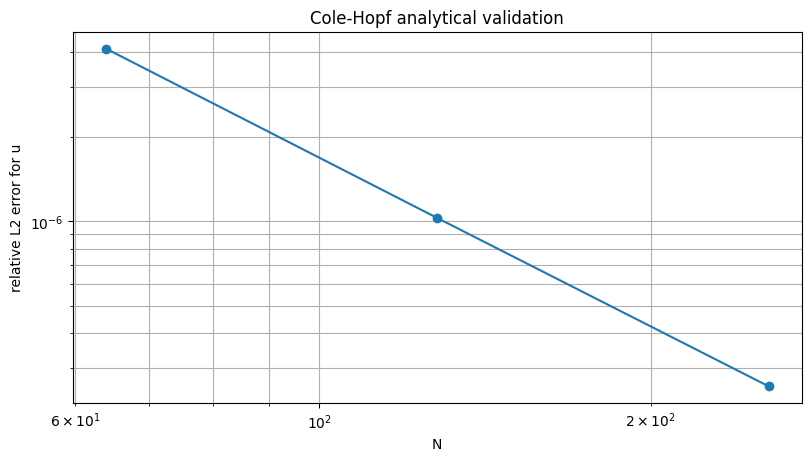

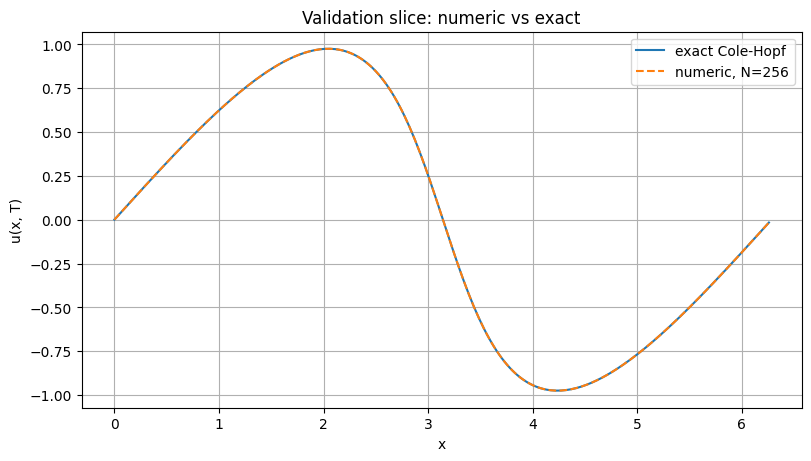

In [9]:
# ============================================================
# 9. Analytical validation example
# ============================================================

RUN_VALIDATION = True

if RUN_VALIDATION:
    validation_df, validation_curves = run_cole_hopf_validation(
        resolutions=(64, 128, 256),
        nu=5e-2,
        t_final=0.5,
        cfl=0.20,
        progress=False,
    )
    display(validation_df)
    plot_validation_results(validation_df, validation_curves)

## 9. Основной 2D-пример при малой вязкости

Этот пример показывает режим, где конвекция доминирует над вязкостью и формируются большие градиенты.

В сценарии используется слабая спектральная стабилизация (`eps4` и `filter_strength`), которая подавляет нефизичные осцилляции около резких фронтов.


step=    1  t=0.00300/0.30000  dt=2.996e-03  energy=5.912462e-01  max_grad=1.886642e+00
step=   50  t=0.14980/0.30000  dt=2.996e-03  energy=5.910572e-01  max_grad=2.058014e+00
step=  100  t=0.29963/0.30000  dt=2.997e-03  energy=5.908532e-01  max_grad=2.565486e+00
step=  101  t=0.30000/0.30000  dt=3.659e-04  energy=5.908526e-01  max_grad=2.567345e+00


### Основной 2D-эксперимент при малой вязкости

#### Сохранённые файлы
- **data**: `burgers2d3d_results/data/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300.npz`
- **history**: `burgers2d3d_results/tables/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_history.csv`
- **meta**: `burgers2d3d_results/data/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_meta.json`

#### Сводка по массивам `burgers2d_low_viscosity_N256x256_nu1e-03_T0p300.npz`

,array,shape,dtype,min,max
0,x,256,float64,0.000000,6.258642
1,y,256,float64,0.000000,6.258642
2,u,256×256,float64,-1.249809,1.249781
3,v,256×256,float64,-1.458698,1.458611
4,t,scalar,float64,0.300000,0.300000
5,step,scalar,int64,101.000000,101.000000


#### Параметры и финальная диагностика `burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_meta.json`

<IPython.core.display.JSON object>

#### История расчёта

,t,step,u_min,u_max,v_min,v_max,energy,max_grad,rms_grad
0,0.000000,0,-1.250000,1.250000,-1.459212,1.459212,0.591250,1.885639,1.128051
1,0.002996,1,-1.249993,1.249993,-1.459170,1.459219,0.591246,1.886642,1.128053
2,0.074897,25,-1.249942,1.249939,-1.459048,1.459046,0.591154,1.939422,1.131637
3,0.149802,50,-1.249901,1.249895,-1.458966,1.458938,0.591057,2.058014,1.142890
4,0.224714,75,-1.249858,1.249846,-1.458737,1.458805,0.590957,2.256592,1.162678
5,0.299634,100,-1.249808,1.249779,-1.458698,1.458606,0.590853,2.565486,1.192700
6,0.300000,101,-1.249809,1.249781,-1.458698,1.458611,0.590853,2.567345,1.192876


#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_fields.png`

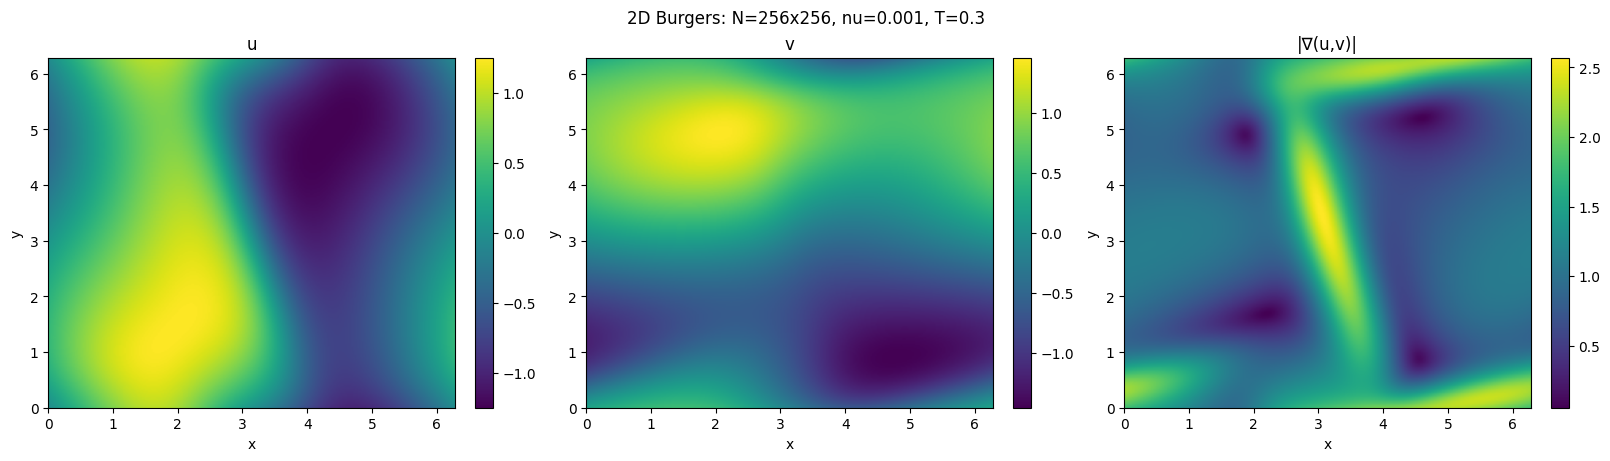

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_centerline.png`

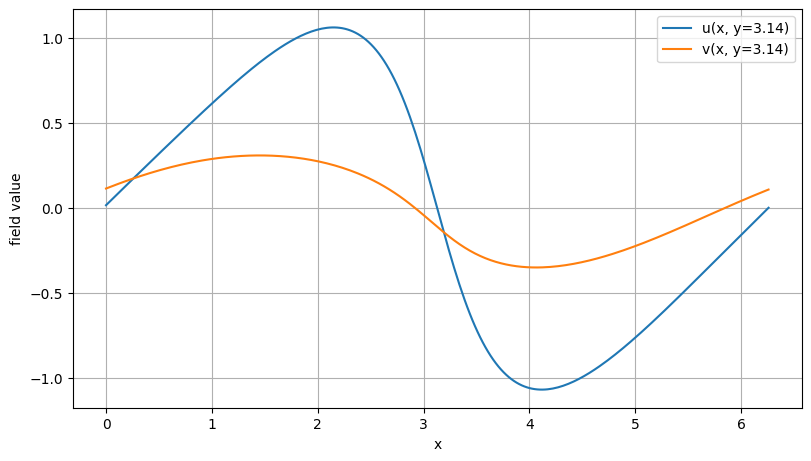

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_energy.png`

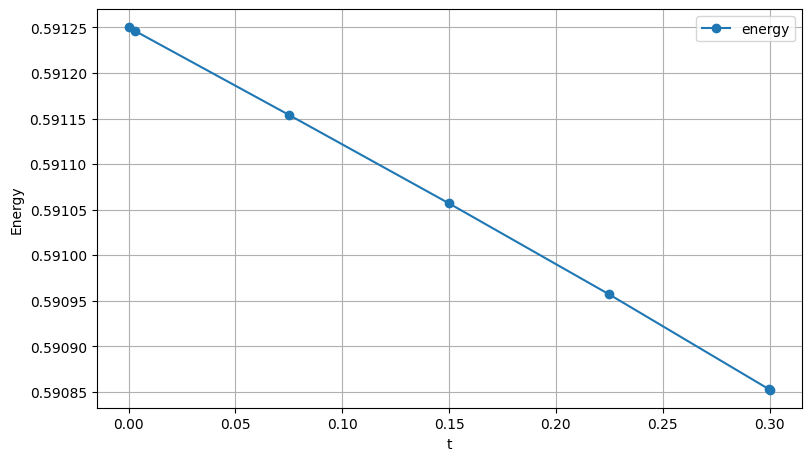

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers2d_low_viscosity_N256x256_nu1e-03_T0p300_energy_max_grad.png`

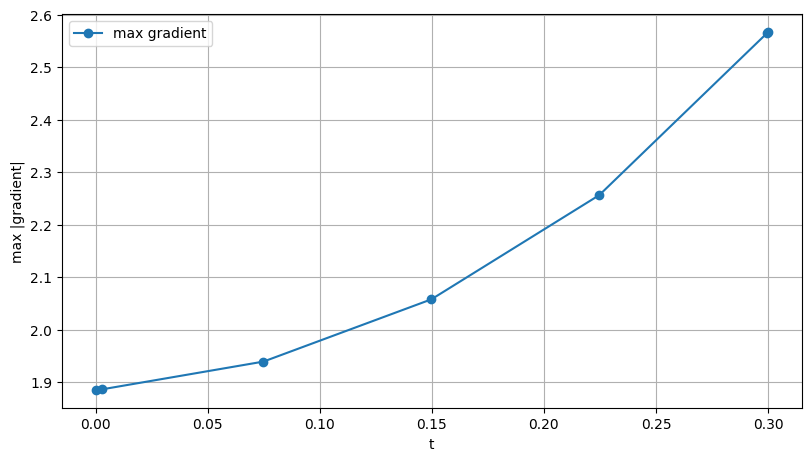

In [10]:
# ============================================================
# 10. Main 2D low-viscosity run
# ============================================================

RUN_LOW_VISCOSITY_2D = True

if RUN_LOW_VISCOSITY_2D:
    cfg_2d = SimulationConfig(
        nx=256,
        ny=256,
        nu=1e-3,
        t_final=0.30,
        cfl=0.20,
        eps4=2e-6,
        filter_strength=18.0,
        filter_order=8,
    )

    run_2d = run_simulation(cfg_2d, ic_2d_smooth_shock_test, save_snapshots=True, snapshot_count=5, progress=True)
    prefix_2d = default_prefix(cfg_2d, tag="burgers2d_low_viscosity")
    saved_2d = save_run(run_2d, prefix_2d)
    display_saved_run(run_2d, saved_2d, title="Основной 2D-эксперимент при малой вязкости")

    plot_fields(run_2d, save_path=IMG_DIR / f"{prefix_2d}_fields.png")
    plot_centerline(run_2d, save_path=IMG_DIR / f"{prefix_2d}_centerline.png")
    plot_history(run_2d, save_path=IMG_DIR / f"{prefix_2d}_energy.png")

## 10. Sweep по вязкости при фиксированных численных параметрах

В этом эксперименте меняется только физическая вязкость $\nu$. Остальные численные параметры остаются фиксированными: размер сетки, конечное время, CFL, гипервязкость и спектральный фильтр.

Такой вариант позволяет корректно сравнить влияние вязкости на величину градиентов в решении.

Переменная `RUN_VISCOSITY_SWEEP` управляет запуском серии расчётов.


step=    1  t=0.00399/0.25000  dt=3.994e-03  energy=5.911992e-01  max_grad=1.886563e+00
step=   50  t=0.19999/0.25000  dt=4.005e-03  energy=5.886711e-01  max_grad=2.168575e+00
step=   63  t=0.25000/0.25000  dt=1.931e-03  energy=5.879986e-01  max_grad=2.326291e+00
step=    1  t=0.00399/0.25000  dt=3.994e-03  energy=5.912246e-01  max_grad=1.886635e+00
step=   50  t=0.19985/0.25000  dt=4.000e-03  energy=5.899594e-01  max_grad=2.174852e+00
step=   63  t=0.25000/0.25000  dt=2.139e-03  energy=5.896210e-01  max_grad=2.337292e+00
step=    1  t=0.00399/0.25000  dt=3.994e-03  energy=5.912449e-01  max_grad=1.886692e+00
step=   50  t=0.19975/0.25000  dt=3.996e-03  energy=5.909914e-01  max_grad=2.179905e+00
step=   63  t=0.25000/0.25000  dt=2.306e-03  energy=5.909233e-01  max_grad=2.346217e+00


#### Сохранена таблица: Sweep по вязкости при фиксированных численных параметрах
- **table**: `burgers2d3d_results/tables/viscosity_sweep_fixed_settings.csv`

#### Sweep по вязкости при фиксированных численных параметрах

,nu,N,T,eps4,filter_strength,steps,u_min,u_max,v_min,v_max,energy,max_grad,rms_grad
0,0.010,192,0.25,0.000001,12.0,63,-1.248434,1.248287,-1.454687,1.454459,0.587999,2.326291,1.167186
1,0.005,192,0.25,0.000001,12.0,63,-1.249217,1.249143,-1.456962,1.456824,0.589621,2.337292,1.169605
2,0.001,192,0.25,0.000001,12.0,63,-1.249841,1.249825,-1.458783,1.458720,0.590923,2.346217,1.171552


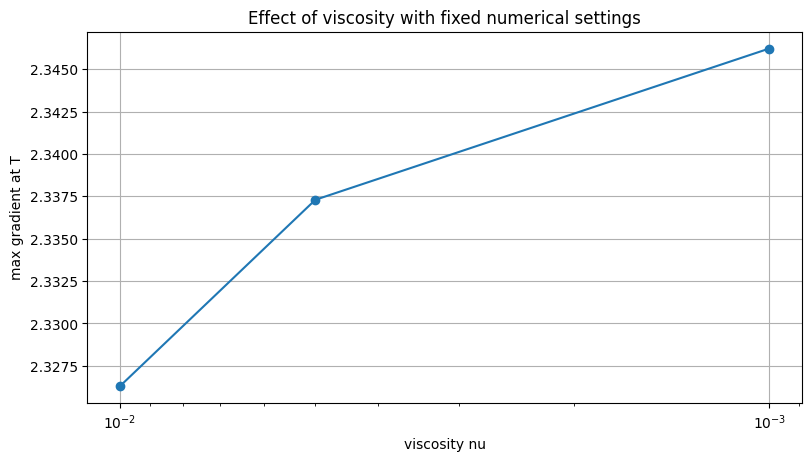

In [11]:
# ============================================================
# 11. Viscosity sweep with fixed numerical settings
# ============================================================

RUN_VISCOSITY_SWEEP = True

if RUN_VISCOSITY_SWEEP:
    nu_values = [1e-2, 5e-3, 1e-3]
    sweep_rows = []

    for nu in nu_values:
        cfg = SimulationConfig(
            nx=192,
            ny=192,
            nu=nu,
            t_final=0.25,
            cfl=0.20,
            eps4=1e-6,             # fixed for all nu
            filter_strength=12.0,  # fixed for all nu
            filter_order=8,
        )
        run = run_simulation(cfg, ic_2d_smooth_shock_test, save_snapshots=False, progress=True)
        prefix = default_prefix(cfg, tag="burgers2d_viscosity_sweep")
        save_run(run, prefix)
        sweep_rows.append({
            "nu": nu,
            "N": cfg.nx,
            "T": cfg.t_final,
            "eps4": cfg.eps4,
            "filter_strength": cfg.filter_strength,
            "steps": run["step"],
            **run["final_stats"],
        })

    viscosity_df = pd.DataFrame(sweep_rows)
    save_dataframe_and_display(
        viscosity_df,
        TABLE_DIR / "viscosity_sweep_fixed_settings.csv",
        "Sweep по вязкости при фиксированных численных параметрах",
    )

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.semilogx(viscosity_df["nu"], viscosity_df["max_grad"], marker="o")
    ax.invert_xaxis()
    ax.set_xlabel("viscosity nu")
    ax.set_ylabel("max gradient at T")
    ax.set_title("Effect of viscosity with fixed numerical settings")
    ax.grid(True)
    fig.savefig(IMG_DIR / "viscosity_sweep_fixed_settings.png", dpi=180)
    plt.show()

## 11. Сравнение с высокоразрешённым reference

Это дополнительная численная проверка для 2D-сценария. Она не заменяет аналитическую валидацию, но позволяет оценить ошибку на грубых сетках относительно расчёта с более высоким разрешением.

В таблице явно сохраняются `N_ref` и `N_test`, поэтому результаты не смешиваются между разными разрешениями.


Running reference: N_ref=512, nu=0.01, T=0.3
step=    1  t=0.00245/0.30000  dt=2.454e-03  energy=2.499755e-01  max_grad=1.414157e+00
step=   50  t=0.12287/0.30000  dt=2.460e-03  energy=2.487713e-01  max_grad=1.442920e+00
step=  100  t=0.24604/0.30000  dt=2.466e-03  energy=2.475266e-01  max_grad=1.540647e+00
step=  122  t=0.30000/0.30000  dt=2.141e-03  energy=2.469720e-01  max_grad=1.608911e+00

Running test grid: N_test=64
step=    1  t=0.01963/0.30000  dt=1.963e-02  energy=2.498037e-01  max_grad=1.414475e+00
step=   16  t=0.30000/0.30000  dt=4.548e-03  energy=2.469719e-01  max_grad=1.608908e+00

Running test grid: N_test=128
step=    1  t=0.00982/0.30000  dt=9.817e-03  energy=2.499018e-01  max_grad=1.414140e+00
step=   31  t=0.30000/0.30000  dt=4.605e-03  energy=2.469720e-01  max_grad=1.608911e+00

Running test grid: N_test=256
step=    1  t=0.00491/0.30000  dt=4.909e-03  energy=2.499509e-01  max_grad=1.414126e+00
step=   50  t=0.24604/0.30000  dt=4.933e-03  energy=2.475266e-01  max_g

#### Сохранена таблица: Сравнение с высокоразрешённым reference N=512
- **table**: `burgers2d3d_results/tables/reference_comparison_Nref512.csv`

#### Сравнение с высокоразрешённым reference N=512

,N_test,N_ref,nu,T,eps4,filter_strength,err_u_rel_l2,err_v_rel_l2,steps_test,steps_ref
0,64,512,0.01,0.3,0.0,0.0,4.225440e-07,4.225440e-07,16,122
1,128,512,0.01,0.3,0.0,0.0,1.008680e-07,1.008680e-07,31,122
2,256,512,0.01,0.3,0.0,0.0,2.046474e-08,2.046474e-08,61,122


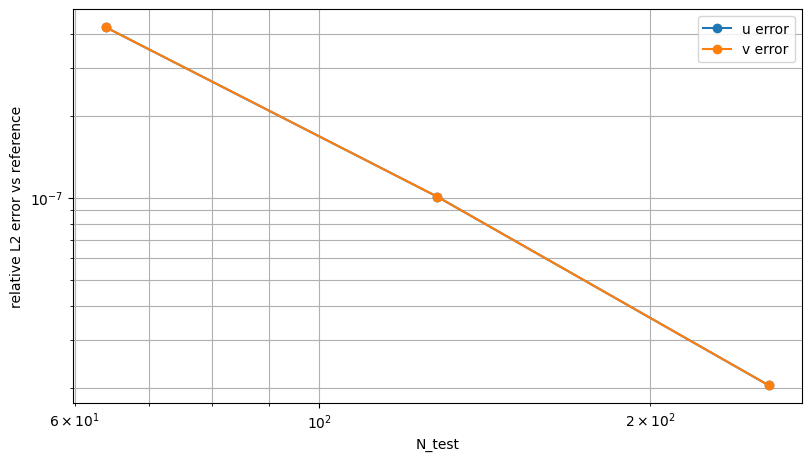

In [12]:
# ============================================================
# 12. Optional high-resolution reference comparison
# ============================================================

def restrict_reference_to_test_grid(ref_field: np.ndarray, n_test: int) -> np.ndarray:
    n_ref_x, n_ref_y = ref_field.shape
    if n_ref_x != n_ref_y:
        raise ValueError("Reference field must be square for this helper")
    if n_ref_x % n_test != 0:
        raise ValueError(f"N_ref={n_ref_x} must be divisible by N_test={n_test}")
    stride = n_ref_x // n_test
    return ref_field[::stride, ::stride]


def compare_to_high_resolution_reference(
    n_test_values: Tuple[int, ...] = (64, 128, 256),
    n_ref: int = 512,
    nu: float = 1e-2,
    t_final: float = 0.30,
) -> pd.DataFrame:
    common = dict(
        nu=nu,
        t_final=t_final,
        cfl=0.20,
        eps4=0.0,
        filter_strength=0.0,
    )

    print(f"Running reference: N_ref={n_ref}, nu={nu:g}, T={t_final:g}")
    cfg_ref = SimulationConfig(nx=n_ref, ny=n_ref, **common)
    ref_run = run_simulation(cfg_ref, ic_2d_taylor_green_like, save_snapshots=False, progress=True)
    ref_prefix = default_prefix(cfg_ref, tag=f"burgers2d_ref_N{n_ref}")
    save_run(ref_run, ref_prefix)

    u_ref = np.array(ref_run["u"])
    v_ref = np.array(ref_run["v"])

    rows = []
    for n_test in n_test_values:
        print(f"\nRunning test grid: N_test={n_test}")
        cfg_test = SimulationConfig(nx=n_test, ny=n_test, **common)
        test_run = run_simulation(cfg_test, ic_2d_taylor_green_like, save_snapshots=False, progress=True)
        test_prefix = default_prefix(cfg_test, tag=f"burgers2d_test_N{n_test}_ref_N{n_ref}")
        save_run(test_run, test_prefix)

        u_test = np.array(test_run["u"])
        v_test = np.array(test_run["v"])
        u_ref_on_test = restrict_reference_to_test_grid(u_ref, n_test)
        v_ref_on_test = restrict_reference_to_test_grid(v_ref, n_test)

        rows.append({
            "N_test": n_test,
            "N_ref": n_ref,
            "nu": nu,
            "T": t_final,
            "eps4": common["eps4"],
            "filter_strength": common["filter_strength"],
            "err_u_rel_l2": relative_l2_error(u_test, u_ref_on_test),
            "err_v_rel_l2": relative_l2_error(v_test, v_ref_on_test),
            "steps_test": test_run["step"],
            "steps_ref": ref_run["step"],
        })

    df = pd.DataFrame(rows)
    save_dataframe_and_display(
        df,
        TABLE_DIR / f"reference_comparison_Nref{n_ref}.csv",
        f"Сравнение с высокоразрешённым reference N={n_ref}",
    )
    return df


RUN_REFERENCE_COMPARISON = True

if RUN_REFERENCE_COMPARISON:
    ref_df = compare_to_high_resolution_reference(
        n_test_values=(64, 128, 256),
        n_ref=512,
        nu=1e-2,
        t_final=0.30,
    )
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.loglog(ref_df["N_test"], ref_df["err_u_rel_l2"], marker="o", label="u error")
    ax.loglog(ref_df["N_test"], ref_df["err_v_rel_l2"], marker="o", label="v error")
    ax.set_xlabel("N_test")
    ax.set_ylabel("relative L2 error vs reference")
    ax.grid(True, which="both")
    ax.legend()
    fig.savefig(IMG_DIR / "reference_comparison_errors.png", dpi=180)
    plt.show()

## 12. Полноценная 3D-постановка

В 3D реализуется векторное вязкое уравнение Бюргерса:

$$
\begin{aligned}
u_t + u u_x + v u_y + w u_z &= \nu \Delta u,\\
v_t + u v_x + v v_y + w v_z &= \nu \Delta v,\\
w_t + u w_x + v w_y + w w_z &= \nu \Delta w.
\end{aligned}
$$

Область расчёта периодическая:

$$
\Omega=[0,2\pi]\times[0,2\pi]\times[0,2\pi].
$$

Для 3D используется та же схема, что и для 2D: спектральные производные, 2/3 de-aliasing, RK4 для нелинейной конвекции и точный диффузионный множитель в Фурье-пространстве.


In [13]:
# ============================================================
# 13. Full 3D solver: configuration, grid and spectral operators
# ============================================================

@dataclass(frozen=True)
class SimulationConfig3D:
    nx: int = 48
    ny: int = 48
    nz: int = 48
    lx: float = 2.0 * math.pi
    ly: float = 2.0 * math.pi
    lz: float = 2.0 * math.pi
    nu: float = 1e-3
    t_final: float = 0.15
    cfl: float = 0.15
    eps4: float = 0.0
    filter_strength: float = 0.0
    filter_order: int = 8
    max_steps: int = 200_000


@dataclass(frozen=True)
class Grid3D:
    nx: int
    ny: int
    nz: int
    lx: float
    ly: float
    lz: float
    dx: float
    dy: float
    dz: float
    x: jnp.ndarray
    y: jnp.ndarray
    z: jnp.ndarray
    X: jnp.ndarray
    Y: jnp.ndarray
    Z: jnp.ndarray
    KX: jnp.ndarray
    KY: jnp.ndarray
    KZ: jnp.ndarray
    K2: jnp.ndarray
    mask: jnp.ndarray


def make_grid3d(
    nx: int,
    ny: int,
    nz: int,
    lx: float = 2.0 * math.pi,
    ly: float = 2.0 * math.pi,
    lz: float = 2.0 * math.pi,
) -> Grid3D:
    """Create a periodic 3D grid and Fourier wave numbers."""
    dx = lx / nx
    dy = ly / ny
    dz = lz / nz

    x = jnp.linspace(0.0, lx, nx, endpoint=False, dtype=REAL)
    y = jnp.linspace(0.0, ly, ny, endpoint=False, dtype=REAL)
    z = jnp.linspace(0.0, lz, nz, endpoint=False, dtype=REAL)
    X, Y, Z = jnp.meshgrid(x, y, z, indexing="ij")

    kx = 2.0 * jnp.pi * jnp.fft.fftfreq(nx, d=float(dx))
    ky = 2.0 * jnp.pi * jnp.fft.fftfreq(ny, d=float(dy))
    kz = 2.0 * jnp.pi * jnp.fft.fftfreq(nz, d=float(dz))
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing="ij")
    K2 = KX**2 + KY**2 + KZ**2

    kx_index = jnp.fft.fftfreq(nx, d=1.0 / nx)
    ky_index = jnp.fft.fftfreq(ny, d=1.0 / ny)
    kz_index = jnp.fft.fftfreq(nz, d=1.0 / nz)
    KX_INDEX, KY_INDEX, KZ_INDEX = jnp.meshgrid(kx_index, ky_index, kz_index, indexing="ij")
    mask = (
        (jnp.abs(KX_INDEX) <= nx / 3.0)
        & (jnp.abs(KY_INDEX) <= ny / 3.0)
        & (jnp.abs(KZ_INDEX) <= nz / 3.0)
    ).astype(REAL)

    return Grid3D(
        nx=nx,
        ny=ny,
        nz=nz,
        lx=lx,
        ly=ly,
        lz=lz,
        dx=float(dx),
        dy=float(dy),
        dz=float(dz),
        x=x,
        y=y,
        z=z,
        X=X,
        Y=Y,
        Z=Z,
        KX=KX.astype(REAL),
        KY=KY.astype(REAL),
        KZ=KZ.astype(REAL),
        K2=K2.astype(REAL),
        mask=mask,
    )


def config3d_to_dict(cfg: SimulationConfig3D) -> Dict[str, float]:
    return asdict(cfg)


def fft3(q: jnp.ndarray) -> jnp.ndarray:
    return jnp.fft.fftn(q, axes=(0, 1, 2))


def ifft3(q_hat: jnp.ndarray) -> jnp.ndarray:
    return jnp.fft.ifftn(q_hat, axes=(0, 1, 2))


def spectral_filter3d(q: jnp.ndarray, mask: jnp.ndarray) -> jnp.ndarray:
    """Apply 2/3 de-aliasing mask in 3D Fourier space."""
    return ifft3(fft3(q) * mask).real.astype(REAL)


def spectral_grad3d(
    q: jnp.ndarray,
    KX: jnp.ndarray,
    KY: jnp.ndarray,
    KZ: jnp.ndarray,
    mask: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Return spectral derivatives q_x, q_y and q_z."""
    q_hat = fft3(q) * mask
    qx = ifft3(1j * KX * q_hat).real.astype(REAL)
    qy = ifft3(1j * KY * q_hat).real.astype(REAL)
    qz = ifft3(1j * KZ * q_hat).real.astype(REAL)
    return qx, qy, qz


def make_spectral_smoother3d(K2: jnp.ndarray, strength: float = 0.0, order: int = 8) -> jnp.ndarray:
    """Exponential high-frequency spectral filter for 3D arrays."""
    if strength <= 0.0:
        return jnp.ones_like(K2, dtype=REAL)

    k2_max = jnp.max(K2)
    eta = jnp.sqrt(jnp.where(k2_max > 0.0, K2 / k2_max, 0.0))
    sigma = jnp.exp(-strength * eta**order)
    return sigma.astype(REAL)


In [14]:
# ============================================================
# 14. Full 3D solver: RHS, time stepping and runner
# ============================================================

@jax.jit
def adv_rhs3d(
    u: jnp.ndarray,
    v: jnp.ndarray,
    w: jnp.ndarray,
    KX: jnp.ndarray,
    KY: jnp.ndarray,
    KZ: jnp.ndarray,
    mask: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Nonlinear convective RHS for the 3D vector Burgers equation."""
    u = spectral_filter3d(u, mask)
    v = spectral_filter3d(v, mask)
    w = spectral_filter3d(w, mask)

    ux, uy, uz = spectral_grad3d(u, KX, KY, KZ, mask)
    vx, vy, vz = spectral_grad3d(v, KX, KY, KZ, mask)
    wx, wy, wz = spectral_grad3d(w, KX, KY, KZ, mask)

    du = -(u * ux + v * uy + w * uz)
    dv = -(u * vx + v * vy + w * vz)
    dw = -(u * wx + v * wy + w * wz)

    du = spectral_filter3d(du, mask)
    dv = spectral_filter3d(dv, mask)
    dw = spectral_filter3d(dw, mask)
    return du.astype(REAL), dv.astype(REAL), dw.astype(REAL)


@jax.jit
def rk4_advective3d(
    u: jnp.ndarray,
    v: jnp.ndarray,
    w: jnp.ndarray,
    dt: jnp.ndarray,
    KX: jnp.ndarray,
    KY: jnp.ndarray,
    KZ: jnp.ndarray,
    mask: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Classical RK4 for the 3D nonlinear advective part."""
    k1u, k1v, k1w = adv_rhs3d(u, v, w, KX, KY, KZ, mask)
    k2u, k2v, k2w = adv_rhs3d(
        u + 0.5 * dt * k1u,
        v + 0.5 * dt * k1v,
        w + 0.5 * dt * k1w,
        KX,
        KY,
        KZ,
        mask,
    )
    k3u, k3v, k3w = adv_rhs3d(
        u + 0.5 * dt * k2u,
        v + 0.5 * dt * k2v,
        w + 0.5 * dt * k2w,
        KX,
        KY,
        KZ,
        mask,
    )
    k4u, k4v, k4w = adv_rhs3d(
        u + dt * k3u,
        v + dt * k3v,
        w + dt * k3w,
        KX,
        KY,
        KZ,
        mask,
    )

    u_next = u + (dt / 6.0) * (k1u + 2.0 * k2u + 2.0 * k3u + k4u)
    v_next = v + (dt / 6.0) * (k1v + 2.0 * k2v + 2.0 * k3v + k4v)
    w_next = w + (dt / 6.0) * (k1w + 2.0 * k2w + 2.0 * k3w + k4w)

    return (
        spectral_filter3d(u_next, mask),
        spectral_filter3d(v_next, mask),
        spectral_filter3d(w_next, mask),
    )


@jax.jit
def strang_rk4_step3d(
    u: jnp.ndarray,
    v: jnp.ndarray,
    w: jnp.ndarray,
    dt: jnp.ndarray,
    nu: jnp.ndarray,
    eps4: jnp.ndarray,
    KX: jnp.ndarray,
    KY: jnp.ndarray,
    KZ: jnp.ndarray,
    K2: jnp.ndarray,
    mask: jnp.ndarray,
    sigma: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """One 3D Strang-splitting step: half diffusion, RK4 advection, half diffusion."""
    damping_half = jnp.exp(-0.5 * dt * (nu * K2 + eps4 * K2**2))

    u = ifft3(fft3(u) * damping_half).real.astype(REAL)
    v = ifft3(fft3(v) * damping_half).real.astype(REAL)
    w = ifft3(fft3(w) * damping_half).real.astype(REAL)

    u, v, w = rk4_advective3d(u, v, w, dt, KX, KY, KZ, mask)

    u = ifft3(fft3(u) * damping_half * sigma).real.astype(REAL)
    v = ifft3(fft3(v) * damping_half * sigma).real.astype(REAL)
    w = ifft3(fft3(w) * damping_half * sigma).real.astype(REAL)

    u = spectral_filter3d(u, mask)
    v = spectral_filter3d(v, mask)
    w = spectral_filter3d(w, mask)
    return u, v, w


def compute_dt3d(
    u: jnp.ndarray,
    v: jnp.ndarray,
    w: jnp.ndarray,
    dx: float,
    dy: float,
    dz: float,
    cfl: float,
    t_remaining: float,
) -> float:
    speed = jnp.sqrt(u * u + v * v + w * w)
    max_speed = float(jnp.max(speed))

    if not math.isfinite(max_speed):
        raise FloatingPointError("Non-finite velocity detected while computing 3D dt")

    if max_speed < 1e-14:
        dt = 1e-3
    else:
        dt = cfl * min(dx, dy, dz) / max_speed

    return max(1e-12, min(dt, t_remaining))


def field_stats3d(u: jnp.ndarray, v: jnp.ndarray, w: jnp.ndarray, grid: Grid3D) -> Dict[str, float]:
    ux, uy, uz = spectral_grad3d(u, grid.KX, grid.KY, grid.KZ, grid.mask)
    vx, vy, vz = spectral_grad3d(v, grid.KX, grid.KY, grid.KZ, grid.mask)
    wx, wy, wz = spectral_grad3d(w, grid.KX, grid.KY, grid.KZ, grid.mask)

    grad_mag = jnp.sqrt(
        ux**2 + uy**2 + uz**2
        + vx**2 + vy**2 + vz**2
        + wx**2 + wy**2 + wz**2
    )
    energy = 0.5 * jnp.mean(u**2 + v**2 + w**2)

    return {
        "u_min": float(jnp.min(u)),
        "u_max": float(jnp.max(u)),
        "v_min": float(jnp.min(v)),
        "v_max": float(jnp.max(v)),
        "w_min": float(jnp.min(w)),
        "w_max": float(jnp.max(w)),
        "energy": float(energy),
        "max_grad": float(jnp.max(grad_mag)),
        "rms_grad": float(jnp.sqrt(jnp.mean(grad_mag**2))),
    }


def run_simulation3d(
    cfg: SimulationConfig3D,
    init_fn: Callable[[Grid3D], Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]],
    save_snapshots: bool = True,
    snapshot_count: int = 4,
    progress: bool = True,
) -> Dict[str, object]:
    """Run one 3D viscous Burgers simulation."""
    grid = make_grid3d(cfg.nx, cfg.ny, cfg.nz, cfg.lx, cfg.ly, cfg.lz)
    u, v, w = init_fn(grid)

    sigma = make_spectral_smoother3d(grid.K2, cfg.filter_strength, cfg.filter_order)

    t = 0.0
    step = 0
    start = time.time()

    history: List[Dict[str, float]] = []
    snapshots: List[Dict[str, object]] = []

    if save_snapshots and snapshot_count > 0:
        snapshot_times = np.linspace(0.0, cfg.t_final, snapshot_count)
        next_snapshot = 0
    else:
        snapshot_times = np.array([], dtype=float)
        next_snapshot = 0

    while t < cfg.t_final - 1e-14:
        if step >= cfg.max_steps:
            raise RuntimeError(f"Maximum number of 3D steps exceeded: {cfg.max_steps}")

        dt = compute_dt3d(u, v, w, grid.dx, grid.dy, grid.dz, cfg.cfl, cfg.t_final - t)

        u, v, w = strang_rk4_step3d(
            u,
            v,
            w,
            jnp.asarray(dt, dtype=REAL),
            jnp.asarray(cfg.nu, dtype=REAL),
            jnp.asarray(cfg.eps4, dtype=REAL),
            grid.KX,
            grid.KY,
            grid.KZ,
            grid.K2,
            grid.mask,
            sigma,
        )

        t += dt
        step += 1

        if step == 1 or step % 20 == 0 or t >= cfg.t_final - 1e-14:
            stats = field_stats3d(u, v, w, grid)
            history.append({"step": step, "t": t, "dt": dt, **stats})
            if progress:
                print(
                    f"3D step={step:5d} t={t:.5f} dt={dt:.2e} "
                    f"E={stats['energy']:.6e} max_grad={stats['max_grad']:.6e}"
                )

        while save_snapshots and next_snapshot < len(snapshot_times) and t >= snapshot_times[next_snapshot] - 1e-14:
            snapshots.append({
                "t": float(t),
                "u": np.array(u),
                "v": np.array(v),
                "w": np.array(w),
            })
            next_snapshot += 1

    elapsed = time.time() - start

    return {
        "config": cfg,
        "grid": grid,
        "u": u,
        "v": v,
        "w": w,
        "t": float(t),
        "step": step,
        "elapsed_sec": elapsed,
        "history": pd.DataFrame(history),
        "snapshots": snapshots,
        "final_stats": field_stats3d(u, v, w, grid),
    }


In [15]:
# ============================================================
# 15. Full 3D solver: initial conditions, saving and plots
# ============================================================

def ic_3d_1d_sine_reduction(grid: Grid3D) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    3D validation initial condition:
        u(x, y, z, 0) = sin(x), v = 0, w = 0.

    The exact solution remains independent of y and z and is given by Cole-Hopf.
    """
    u0 = jnp.sin(grid.X).astype(REAL)
    v0 = jnp.zeros_like(u0, dtype=REAL)
    w0 = jnp.zeros_like(u0, dtype=REAL)
    return u0, v0, w0


def ic_3d_smooth_shock_test(grid: Grid3D) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Smooth 3D initial field that develops steep gradients in the low-viscosity regime.
    """
    X, Y, Z = grid.X, grid.Y, grid.Z
    u0 = jnp.sin(X) + 0.30 * jnp.sin(Y) + 0.20 * jnp.sin(Z) + 0.10 * jnp.sin(2.0 * X + Y - Z)
    v0 = -jnp.sin(Y) + 0.25 * jnp.sin(Z) + 0.15 * jnp.cos(X - Z) + 0.10 * jnp.sin(X + 2.0 * Y)
    w0 = 0.60 * jnp.sin(Z) + 0.20 * jnp.cos(X + Y) + 0.10 * jnp.sin(Y + 2.0 * Z)
    return u0.astype(REAL), v0.astype(REAL), w0.astype(REAL)


def default_prefix3d(cfg: SimulationConfig3D, tag: str = "burgers3d") -> str:
    return f"{tag}_N{cfg.nx}x{cfg.ny}x{cfg.nz}_nu{safe_float_token(cfg.nu)}_T{cfg.t_final:.3f}".replace(".", "p")


def save_run3d(run: Dict[str, object], prefix: Optional[str] = None) -> Dict[str, Path]:
    cfg: SimulationConfig3D = run["config"]
    grid: Grid3D = run["grid"]
    if prefix is None:
        prefix = default_prefix3d(cfg)

    data_path = DATA_DIR / f"{prefix}.npz"
    history_path = TABLE_DIR / f"{prefix}_history.csv"
    meta_path = DATA_DIR / f"{prefix}_meta.json"

    np.savez_compressed(
        data_path,
        x=np.array(grid.x),
        y=np.array(grid.y),
        z=np.array(grid.z),
        u=np.array(run["u"]),
        v=np.array(run["v"]),
        w=np.array(run["w"]),
        t=np.array(run["t"]),
        step=np.array(run["step"]),
    )

    run["history"].to_csv(history_path, index=False)

    meta = {
        "config": config3d_to_dict(cfg),
        "t": run["t"],
        "step": run["step"],
        "elapsed_sec": run["elapsed_sec"],
        "final_stats": run["final_stats"],
    }
    meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

    return {"data": data_path, "history": history_path, "meta": meta_path}


def compute_gradient_magnitude3d(u: jnp.ndarray, v: jnp.ndarray, w: jnp.ndarray, grid: Grid3D) -> jnp.ndarray:
    ux, uy, uz = spectral_grad3d(u, grid.KX, grid.KY, grid.KZ, grid.mask)
    vx, vy, vz = spectral_grad3d(v, grid.KX, grid.KY, grid.KZ, grid.mask)
    wx, wy, wz = spectral_grad3d(w, grid.KX, grid.KY, grid.KZ, grid.mask)
    return jnp.sqrt(
        ux**2 + uy**2 + uz**2
        + vx**2 + vy**2 + vz**2
        + wx**2 + wy**2 + wz**2
    )


def plot_slices3d(run: Dict[str, object], title: Optional[str] = None, save_path: Optional[Path] = None):
    """Plot mid-z slices of u, v, w and the full 3D gradient magnitude."""
    grid: Grid3D = run["grid"]
    cfg: SimulationConfig3D = run["config"]
    z_idx = grid.nz // 2

    u = np.array(run["u"])[:, :, z_idx]
    v = np.array(run["v"])[:, :, z_idx]
    w = np.array(run["w"])[:, :, z_idx]
    grad = np.array(compute_gradient_magnitude3d(run["u"], run["v"], run["w"], grid))[:, :, z_idx]

    extent = [0.0, grid.lx, 0.0, grid.ly]
    if title is None:
        title = f"3D Burgers mid-z slices: N={cfg.nx}x{cfg.ny}x{cfg.nz}, nu={cfg.nu:g}, T={cfg.t_final:g}"

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
    fields = [(u.T, "u"), (v.T, "v"), (w.T, "w"), (grad.T, "|∇(u,v,w)|")]
    for ax, (data, name) in zip(axes.ravel(), fields):
        im = ax.imshow(data, origin="lower", extent=extent, aspect="auto")
        ax.set_title(f"{name}, z={float(grid.z[z_idx]):.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax)
    fig.suptitle(title)

    save_figure(fig, save_path)
    plt.show()


def plot_centerline3d(run: Dict[str, object], save_path: Optional[Path] = None):
    """Plot x-centerline at fixed y and z."""
    grid: Grid3D = run["grid"]
    u = np.array(run["u"])
    v = np.array(run["v"])
    w = np.array(run["w"])
    y_idx = grid.ny // 2
    z_idx = grid.nz // 2

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(np.array(grid.x), u[:, y_idx, z_idx], label="u")
    ax.plot(np.array(grid.x), v[:, y_idx, z_idx], label="v")
    ax.plot(np.array(grid.x), w[:, y_idx, z_idx], label="w")
    ax.set_xlabel("x")
    ax.set_ylabel("field value")
    ax.set_title(f"3D centerline at y={float(grid.y[y_idx]):.2f}, z={float(grid.z[z_idx]):.2f}")
    ax.grid(True)
    ax.legend()

    save_figure(fig, save_path)
    plt.show()


def plot_history3d(run: Dict[str, object], save_path: Optional[Path] = None):
    """Plot energy and maximum gradient history for a 3D run."""
    hist = run["history"]

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(hist["t"], hist["energy"], marker="o", label="energy")
    ax.set_xlabel("t")
    ax.set_ylabel("Energy")
    ax.grid(True)
    ax.legend()
    save_figure(fig, save_path)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(hist["t"], hist["max_grad"], marker="o", label="max gradient")
    ax.set_xlabel("t")
    ax.set_ylabel("max |gradient|")
    ax.grid(True)
    ax.legend()
    grad_path = save_path.with_name(save_path.stem + "_max_grad" + save_path.suffix) if save_path is not None else None
    save_figure(fig, grad_path)
    plt.show()


## 13. Аналитическая валидация 3D-солвера

Для проверки 3D-солвера используется та же идея 1D-редукции:

$$
u(x,y,z,0)=\sin x,\qquad v(x,y,z,0)=0,\qquad w(x,y,z,0)=0.
$$

Тогда точное решение не зависит от $y$ и $z$, а 3D-система сводится к 1D уравнению Бюргерса:

$$
u_t + u u_x = \nu u_{xx}.
$$

Численное решение 3D-солвера сравнивается с аналитическим решением Коула — Хопфа по срезу $u(x,0,0,t)$. Дополнительно контролируется, что компоненты $v$ и $w$ остаются близкими к нулю.


In [16]:
# ============================================================
# 16. 3D analytical validation
# ============================================================

def run_cole_hopf_validation3d(
    resolutions: Tuple[int, ...] = (24, 32, 48),
    nu: float = 5e-2,
    t_final: float = 0.35,
    cfl: float = 0.15,
    progress: bool = False,
) -> Tuple[pd.DataFrame, Dict[int, Dict[str, np.ndarray]]]:
    """Run analytical validation for the 3D solver using 1D reduction."""
    rows = []
    curves: Dict[int, Dict[str, np.ndarray]] = {}

    for n in resolutions:
        print(f"\n3D validation run: N={n}^3, nu={nu:g}, T={t_final:g}")
        cfg = SimulationConfig3D(
            nx=n,
            ny=n,
            nz=n,
            nu=nu,
            t_final=t_final,
            cfl=cfl,
            eps4=0.0,
            filter_strength=0.0,
        )
        run = run_simulation3d(cfg, ic_3d_1d_sine_reduction, save_snapshots=False, progress=progress)

        x_exact, u_exact = cole_hopf_exact_sine_on_grid(n=n, t=t_final, nu=nu, oversample=16)
        u_num = np.array(run["u"])[:, 0, 0]
        v_num = np.array(run["v"])
        w_num = np.array(run["w"])

        err_u = relative_l2_error(u_num, u_exact)
        v_rms = float(np.sqrt(np.mean(v_num**2)))
        w_rms = float(np.sqrt(np.mean(w_num**2)))

        rows.append({
            "dimension": "3D",
            "N": n,
            "nu": nu,
            "T": t_final,
            "steps": run["step"],
            "err_u_rel_l2": err_u,
            "v_rms": v_rms,
            "w_rms": w_rms,
            "energy": run["final_stats"]["energy"],
            "max_grad": run["final_stats"]["max_grad"],
        })

        curves[n] = {
            "x": x_exact,
            "u_exact": u_exact,
            "u_num": u_num,
        }

    df = pd.DataFrame(rows)
    save_dataframe_and_display(
        df,
        TABLE_DIR / "cole_hopf_validation_3d.csv",
        "Аналитическая валидация 3D-солвера через Cole-Hopf",
    )
    return df, curves


def plot_validation_results3d(df: pd.DataFrame, curves: Dict[int, Dict[str, np.ndarray]]) -> None:
    """Plot 3D validation errors and the finest-grid exact/numerical curve."""
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.loglog(df["N"], df["err_u_rel_l2"], marker="o")
    ax.set_xlabel("N")
    ax.set_ylabel("relative L2 error")
    ax.set_title("3D solver validation by 1D Cole-Hopf reduction")
    ax.grid(True, which="both")
    save_figure(fig, IMG_DIR / "cole_hopf_validation_3d_error.png")
    plt.show()

    finest_n = int(max(curves))
    curve = curves[finest_n]
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(curve["x"], curve["u_exact"], label="exact Cole-Hopf")
    ax.plot(curve["x"], curve["u_num"], "--", label=f"3D numerical, N={finest_n}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,0,0,T)")
    ax.set_title("3D validation: exact vs numerical centerline")
    ax.grid(True)
    ax.legend()
    save_figure(fig, IMG_DIR / "cole_hopf_validation_3d_curve.png")
    plt.show()



3D validation run: N=24^3, nu=0.05, T=0.35

3D validation run: N=32^3, nu=0.05, T=0.35

3D validation run: N=48^3, nu=0.05, T=0.35


#### Сохранена таблица: Аналитическая валидация 3D-солвера через Cole-Hopf
- **table**: `burgers2d3d_results/tables/cole_hopf_validation_3d.csv`

#### Аналитическая валидация 3D-солвера через Cole-Hopf

,dimension,N,nu,T,steps,err_u_rel_l2,v_rms,w_rms,energy,max_grad
0,3D,24,0.05,0.35,9,0.000053,0.0,0.0,0.241140,1.477101
1,3D,32,0.05,0.35,12,0.000008,0.0,0.0,0.241140,1.477683
2,3D,48,0.05,0.35,18,0.000002,0.0,0.0,0.241141,1.477808


,dimension,N,nu,T,steps,err_u_rel_l2,v_rms,w_rms,energy,max_grad
0,3D,24,0.05,0.35,9,0.000053,0.0,0.0,0.241140,1.477101
1,3D,32,0.05,0.35,12,0.000008,0.0,0.0,0.241140,1.477683
2,3D,48,0.05,0.35,18,0.000002,0.0,0.0,0.241141,1.477808


#### Сохранён график
- **image**: `burgers2d3d_results/images/cole_hopf_validation_3d_error.png`

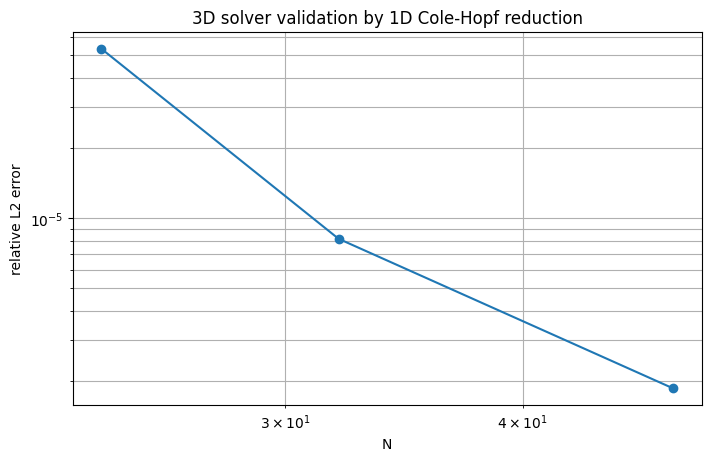

#### Сохранён график
- **image**: `burgers2d3d_results/images/cole_hopf_validation_3d_curve.png`

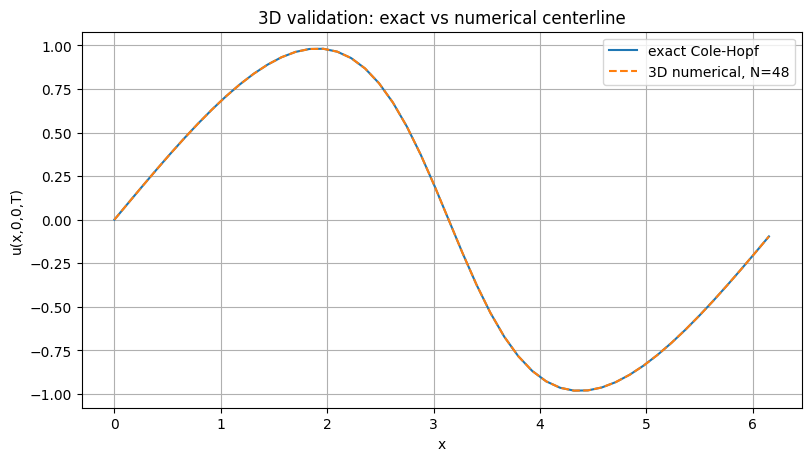

In [17]:
# ============================================================
# 17. Run 3D analytical validation
# ============================================================

RUN_VALIDATION_3D = True

if RUN_VALIDATION_3D:
    validation3d_df, validation3d_curves = run_cole_hopf_validation3d(
        resolutions=(24, 32, 48),
        nu=5e-2,
        t_final=0.35,
        cfl=0.15,
        progress=False,
    )
    display(validation3d_df)
    plot_validation_results3d(validation3d_df, validation3d_curves)


## 14. Основной 3D-пример при малой вязкости

Этот расчёт демонстрирует полноценную 3D-версию вязкого уравнения Бюргерса. Визуализация строится по среднему срезу $z=L_z/2$, а в диагностике контролируются энергия и максимальный модуль градиента во всём трёхмерном поле.


3D step=    1 t=0.00947 dt=9.47e-03 E=6.612365e-01 max_grad=1.917057e+00
3D step=   16 t=0.15000 dt=7.95e-03 E=6.610254e-01 max_grad=2.157964e+00


### Основной 3D-эксперимент при малой вязкости

#### Сохранённые файлы
- **data**: `burgers2d3d_results/data/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150.npz`
- **history**: `burgers2d3d_results/tables/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_history.csv`
- **meta**: `burgers2d3d_results/data/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_meta.json`

#### Сводка по массивам `burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150.npz`

,array,shape,dtype,min,max
0,x,48,float64,0.000000,6.152286
1,y,48,float64,0.000000,6.152286
2,z,48,float64,0.000000,6.152286
3,u,48×48×48,float64,-1.544544,1.544490
4,v,48×48×48,float64,-1.498357,1.317693
5,w,48×48×48,float64,-0.899389,0.899213
6,t,scalar,float64,0.150000,0.150000
7,step,scalar,int64,16.000000,16.000000


#### Параметры и финальная диагностика `burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_meta.json`

<IPython.core.display.JSON object>

#### История расчёта

,step,t,dt,u_min,u_max,v_min,v_max,w_min,w_max,energy,max_grad,rms_grad
0,1,0.00947,0.009470,-1.545305,1.545209,-1.499828,1.316631,-0.899914,0.899878,0.661237,1.917057,1.191138
1,16,0.15000,0.007946,-1.544544,1.544490,-1.498357,1.317693,-0.899389,0.899213,0.661025,2.157964,1.201012


#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_mid_z_slices.png`

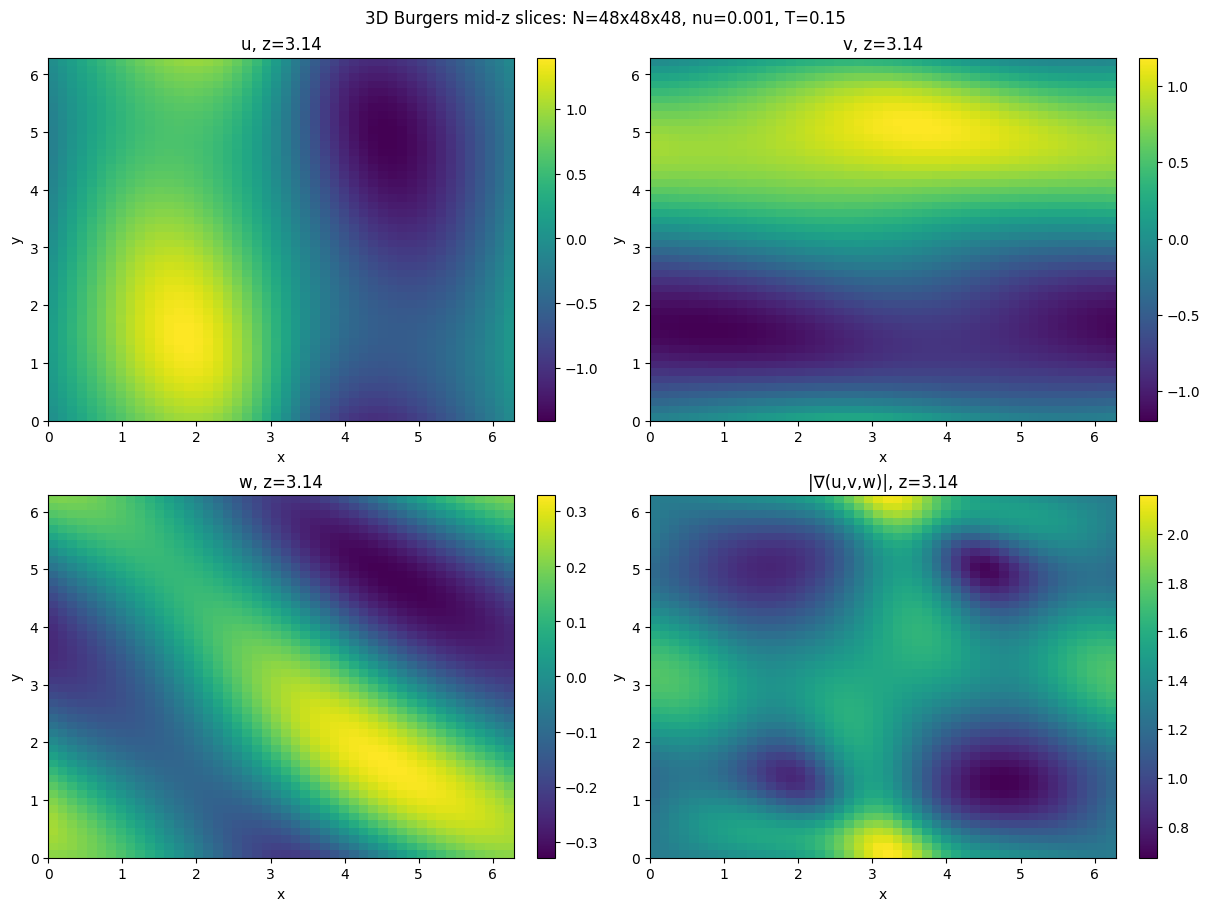

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_centerline.png`

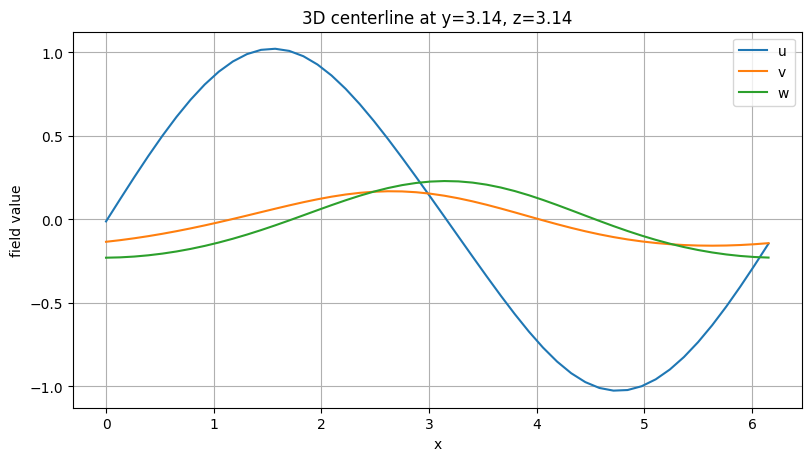

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_energy.png`

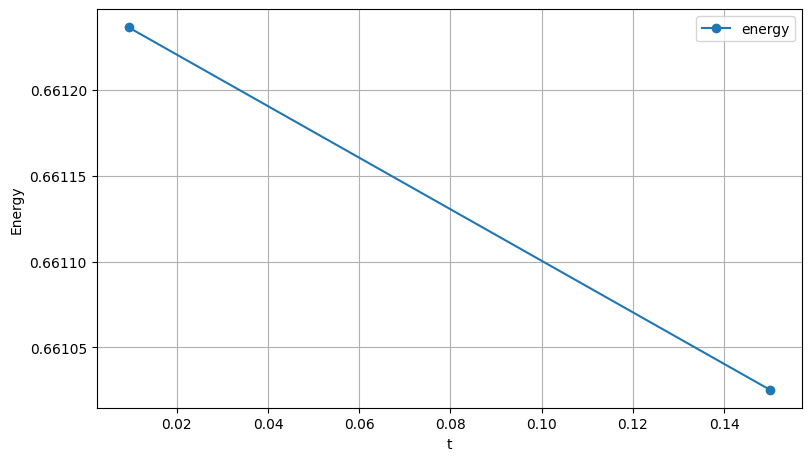

#### Сохранён график
- **image**: `burgers2d3d_results/images/burgers3d_low_viscosity_N48x48x48_nu1e-03_T0p150_energy_max_grad.png`

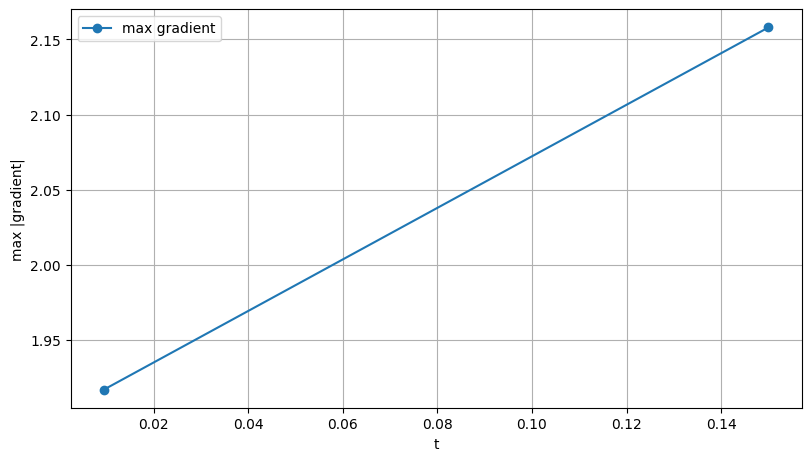

In [18]:
# ============================================================
# 18. Main 3D low-viscosity run
# ============================================================

RUN_LOW_VISCOSITY_3D = True

if RUN_LOW_VISCOSITY_3D:
    cfg_3d = SimulationConfig3D(
        nx=48,
        ny=48,
        nz=48,
        nu=1e-3,
        t_final=0.15,
        cfl=0.15,
        eps4=1e-6,
        filter_strength=14.0,
        filter_order=8,
    )

    run_3d = run_simulation3d(cfg_3d, ic_3d_smooth_shock_test, save_snapshots=True, snapshot_count=4, progress=True)
    prefix_3d = default_prefix3d(cfg_3d, tag="burgers3d_low_viscosity")
    saved_3d = save_run3d(run_3d, prefix_3d)
    display_saved_run(run_3d, saved_3d, title="Основной 3D-эксперимент при малой вязкости")

    plot_slices3d(run_3d, save_path=IMG_DIR / f"{prefix_3d}_mid_z_slices.png")
    plot_centerline3d(run_3d, save_path=IMG_DIR / f"{prefix_3d}_centerline.png")
    plot_history3d(run_3d, save_path=IMG_DIR / f"{prefix_3d}_energy.png")


Saved: burgers2d3d_results/images/burgers2d_evolution_u.png


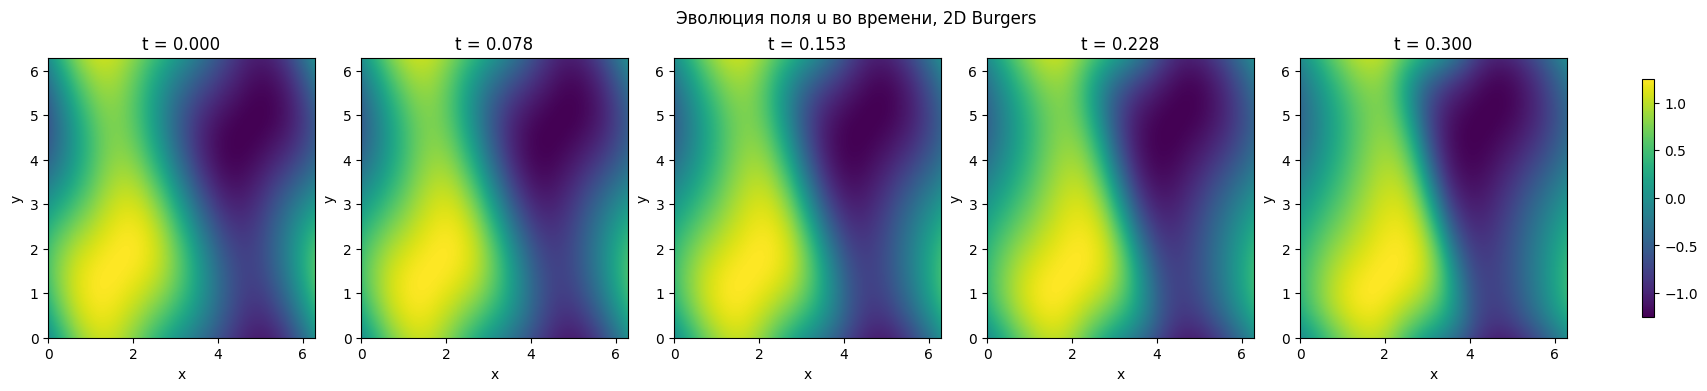

Saved: burgers2d3d_results/images/burgers2d_evolution_speed.png


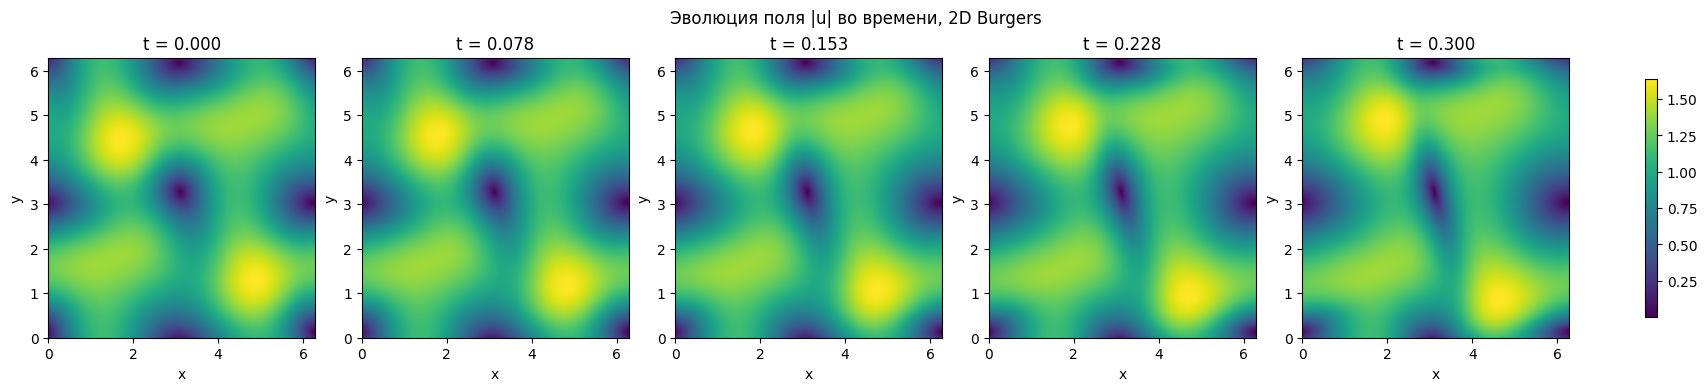

In [19]:
# ============================================================
# Additional plot: 2D field evolution in time
# ============================================================

def plot_2d_evolution(run, component="u", save_path=None):
    """
    Plot evolution of a selected 2D field component over saved snapshots.

    component:
        "u"     - first velocity component
        "v"     - second velocity component
        "speed" - sqrt(u^2 + v^2)
    """
    snapshots = run.get("snapshots", [])
    if len(snapshots) == 0:
        raise ValueError(
            "No snapshots found. Run the solver with save_snapshots=True and snapshot_count > 0."
        )

    grid = run["grid"]
    extent = [0.0, grid.lx, 0.0, grid.ly]

    fields = []
    titles = []

    for snap in snapshots:
        u = np.asarray(snap["u"])
        v = np.asarray(snap["v"])

        if component == "u":
            field = u
            label = "u"
        elif component == "v":
            field = v
            label = "v"
        elif component == "speed":
            field = np.sqrt(u**2 + v**2)
            label = "|u|"
        else:
            raise ValueError("component must be 'u', 'v' or 'speed'")

        fields.append(field)
        titles.append(f"t = {snap['t']:.3f}")

    vmin = min(float(np.min(f)) for f in fields)
    vmax = max(float(np.max(f)) for f in fields)

    n = len(fields)
    fig, axes = plt.subplots(
        1, n,
        figsize=(3.4 * n, 3.8),
        constrained_layout=True
    )

    if n == 1:
        axes = [axes]

    for ax, field, title in zip(axes, fields, titles):
        im = ax.imshow(
            field.T,
            origin="lower",
            extent=extent,
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.colorbar(im, ax=axes, shrink=0.85)
    fig.suptitle(f"Эволюция поля {label} во времени, 2D Burgers")

    if save_path is not None:
        fig.savefig(save_path, dpi=180)
        print("Saved:", save_path)

    plt.show()


plot_2d_evolution(
    run_2d,
    component="u",
    save_path=IMG_DIR / "burgers2d_evolution_u.png"
)

plot_2d_evolution(
    run_2d,
    component="speed",
    save_path=IMG_DIR / "burgers2d_evolution_speed.png"
)

Saved: burgers2d3d_results/images/burgers3d_evolution_u_mid_z.png


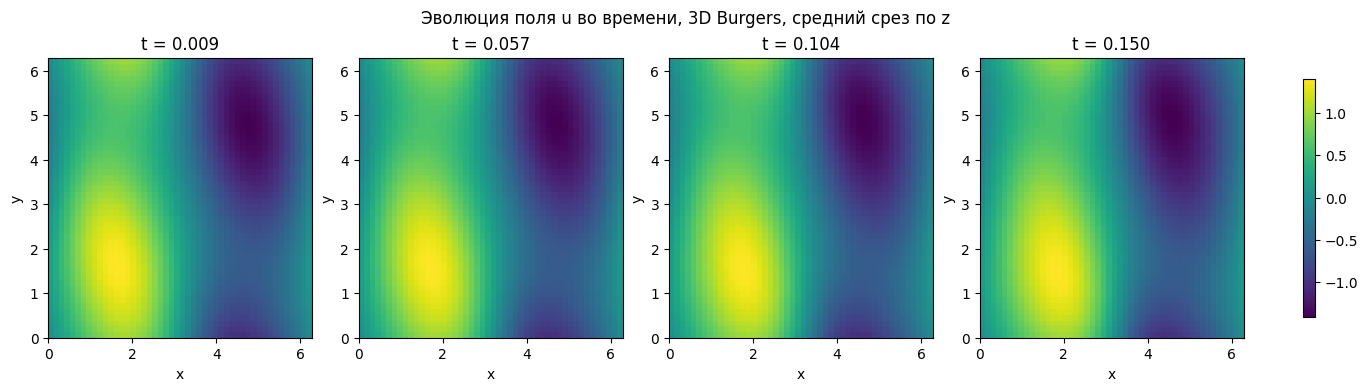

Saved: burgers2d3d_results/images/burgers3d_evolution_speed_mid_z.png


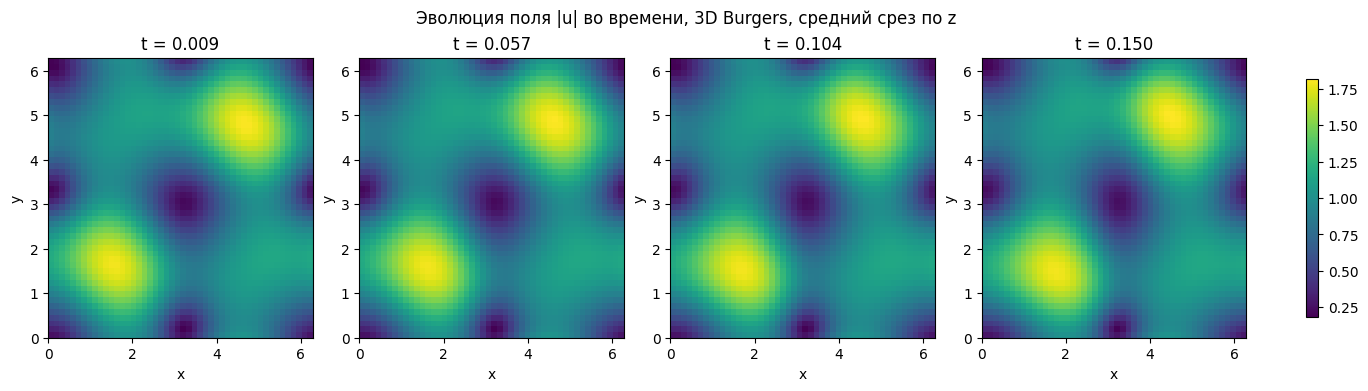

In [20]:
# ============================================================
# Additional plot: 3D field evolution in time using mid-z slices
# ============================================================

def plot_3d_evolution_mid_z(run, component="u", save_path=None):
    """
    Plot evolution of a selected 3D field component using middle z-slices.

    component:
        "u"     - first velocity component
        "v"     - second velocity component
        "w"     - third velocity component
        "speed" - sqrt(u^2 + v^2 + w^2)
    """
    snapshots = run.get("snapshots", [])
    if len(snapshots) == 0:
        raise ValueError(
            "No snapshots found. Run the 3D solver with save_snapshots=True and snapshot_count > 0."
        )

    grid = run["grid"]
    z_idx = grid.nz // 2
    extent = [0.0, grid.lx, 0.0, grid.ly]

    fields = []
    titles = []

    for snap in snapshots:
        u = np.asarray(snap["u"])
        v = np.asarray(snap["v"])
        w = np.asarray(snap["w"])

        if component == "u":
            field = u[:, :, z_idx]
            label = "u"
        elif component == "v":
            field = v[:, :, z_idx]
            label = "v"
        elif component == "w":
            field = w[:, :, z_idx]
            label = "w"
        elif component == "speed":
            field = np.sqrt(u**2 + v**2 + w**2)[:, :, z_idx]
            label = "|u|"
        else:
            raise ValueError("component must be 'u', 'v', 'w' or 'speed'")

        fields.append(field)
        titles.append(f"t = {snap['t']:.3f}")

    vmin = min(float(np.min(f)) for f in fields)
    vmax = max(float(np.max(f)) for f in fields)

    n = len(fields)
    fig, axes = plt.subplots(
        1, n,
        figsize=(3.4 * n, 3.8),
        constrained_layout=True
    )

    if n == 1:
        axes = [axes]

    for ax, field, title in zip(axes, fields, titles):
        im = ax.imshow(
            field.T,
            origin="lower",
            extent=extent,
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.colorbar(im, ax=axes, shrink=0.85)
    fig.suptitle(f"Эволюция поля {label} во времени, 3D Burgers, средний срез по z")

    if save_path is not None:
        fig.savefig(save_path, dpi=180)
        print("Saved:", save_path)

    plt.show()


plot_3d_evolution_mid_z(
    run_3d,
    component="u",
    save_path=IMG_DIR / "burgers3d_evolution_u_mid_z.png"
)

plot_3d_evolution_mid_z(
    run_3d,
    component="speed",
    save_path=IMG_DIR / "burgers3d_evolution_speed_mid_z.png"
)


Temporal convergence run: N=128, CFL=0.4, nu=0.05, T=0.5

Temporal convergence run: N=128, CFL=0.2, nu=0.05, T=0.5

Temporal convergence run: N=128, CFL=0.1, nu=0.05, T=0.5

Temporal convergence run: N=128, CFL=0.05, nu=0.05, T=0.5


#### Сохранена таблица: Проверка временной сходимости 2D-солвера
- **table**: `burgers2d3d_results/tables/temporal_convergence_2d.csv`

#### Проверка временной сходимости 2D-солвера

,N,nu,T,CFL,steps,avg_dt,elapsed_sec,err_u_rel_l2,max_abs_v
0,128,0.05,0.5,0.40,26,0.019231,0.764712,4.099512e-06,0.0
1,128,0.05,0.5,0.20,51,0.009804,1.235714,1.027186e-06,0.0
2,128,0.05,0.5,0.10,101,0.004950,1.553184,2.578494e-07,0.0
3,128,0.05,0.5,0.05,202,0.002475,3.129958,6.480906e-08,0.0


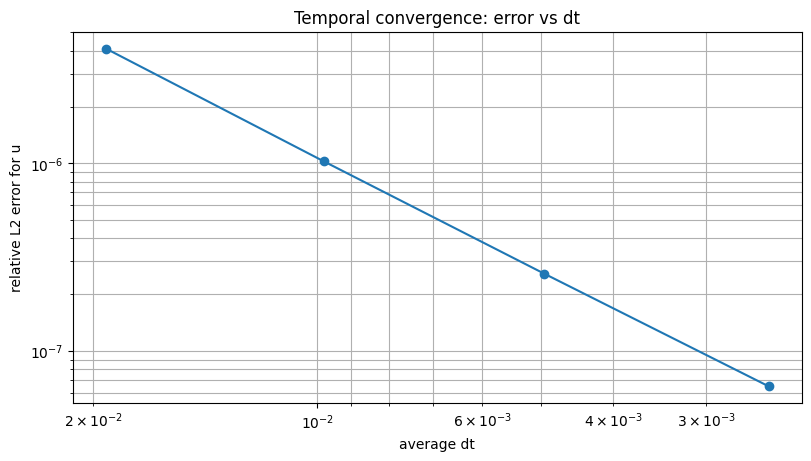

In [21]:
# ============================================================
# Additional experiment: temporal convergence check
# ============================================================

RUN_TEMPORAL_CONVERGENCE_2D = True

def run_temporal_convergence_2d(
    n=128,
    nu=5e-2,
    t_final=0.5,
    cfl_values=(0.40, 0.20, 0.10, 0.05),
):
    """
    Temporal convergence test for the 2D solver using Cole-Hopf analytical solution.

    We keep spatial resolution fixed and decrease CFL, hence decreasing dt.
    """
    rows = []

    x_exact, u_exact_1d = cole_hopf_exact_sine_on_grid(
        n=n,
        t=t_final,
        nu=nu,
        oversample=16
    )
    u_exact_2d = u_exact_1d[:, None] * np.ones((1, n))

    for cfl in cfl_values:
        print(f"\nTemporal convergence run: N={n}, CFL={cfl}, nu={nu:g}, T={t_final:g}")

        cfg = SimulationConfig(
            nx=n,
            ny=n,
            nu=nu,
            t_final=t_final,
            cfl=cfl,
            eps4=0.0,
            filter_strength=0.0,
        )

        run = run_simulation(
            cfg,
            ic_1d_sine_reduction,
            save_snapshots=False,
            progress=False,
        )

        u_num = np.asarray(run["u"])
        v_num = np.asarray(run["v"])

        err_u = relative_l2_error(u_num, u_exact_2d)
        max_abs_v = float(np.max(np.abs(v_num)))

        avg_dt = t_final / run["step"]

        rows.append({
            "N": n,
            "nu": nu,
            "T": t_final,
            "CFL": cfl,
            "steps": run["step"],
            "avg_dt": avg_dt,
            "elapsed_sec": run["elapsed_sec"],
            "err_u_rel_l2": err_u,
            "max_abs_v": max_abs_v,
        })

    df = pd.DataFrame(rows)

    save_dataframe_and_display(
        df,
        TABLE_DIR / "temporal_convergence_2d.csv",
        "Проверка временной сходимости 2D-солвера"
    )

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.loglog(df["avg_dt"], df["err_u_rel_l2"], marker="o")
    ax.invert_xaxis()
    ax.set_xlabel("average dt")
    ax.set_ylabel("relative L2 error for u")
    ax.set_title("Temporal convergence: error vs dt")
    ax.grid(True, which="both")
    fig.savefig(IMG_DIR / "temporal_convergence_2d_error_vs_dt.png", dpi=180)
    plt.show()

    return df


if RUN_TEMPORAL_CONVERGENCE_2D:
    temporal_convergence_2d_df = run_temporal_convergence_2d()


Timing run: N=64, nu=0.01, T=0.25, CFL=0.2

Timing run: N=128, nu=0.01, T=0.25, CFL=0.2

Timing run: N=256, nu=0.01, T=0.25, CFL=0.2


#### Сохранена таблица: Зависимость времени расчёта от размера сетки
- **table**: `burgers2d3d_results/tables/timing_study_2d_by_grid.csv`

#### Зависимость времени расчёта от размера сетки

,N,grid_points,nu,T,CFL,steps,elapsed_sec,sec_per_step,energy,max_grad
0,64,4096,0.01,0.25,0.2,13,0.058239,0.004480,0.247486,1.545081
1,128,16384,0.01,0.25,0.2,26,0.455024,0.017501,0.247486,1.545082
2,256,65536,0.01,0.25,0.2,51,4.870846,0.095507,0.247486,1.545083


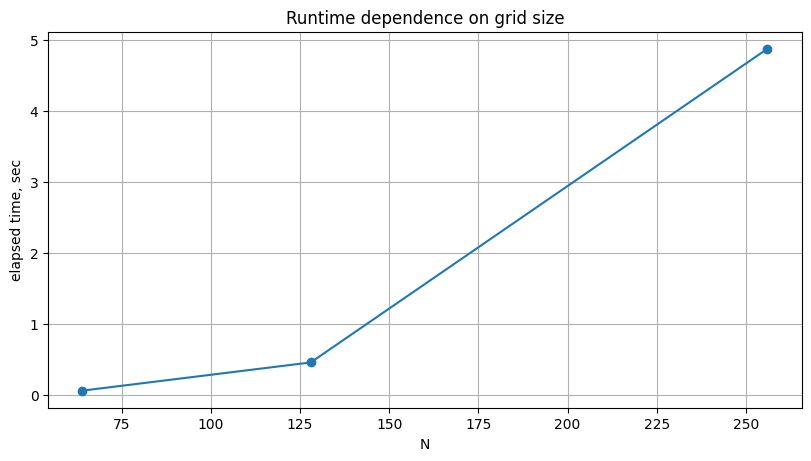

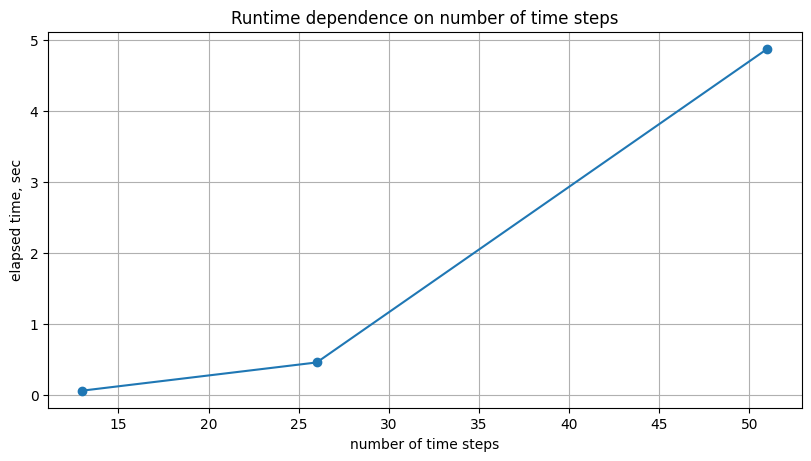

In [22]:
# ============================================================
# Additional experiment: runtime dependence on grid size and number of steps
# ============================================================

RUN_TIMING_STUDY_2D = True

def run_timing_study_2d(
    n_values=(64, 128, 256),
    nu=1e-2,
    t_final=0.25,
    cfl=0.20,
):
    rows = []

    for n in n_values:
        print(f"\nTiming run: N={n}, nu={nu:g}, T={t_final:g}, CFL={cfl}")

        cfg = SimulationConfig(
            nx=n,
            ny=n,
            nu=nu,
            t_final=t_final,
            cfl=cfl,
            eps4=0.0,
            filter_strength=0.0,
        )

        run = run_simulation(
            cfg,
            ic_2d_taylor_green_like,
            save_snapshots=False,
            progress=False,
        )

        rows.append({
            "N": n,
            "grid_points": n * n,
            "nu": nu,
            "T": t_final,
            "CFL": cfl,
            "steps": run["step"],
            "elapsed_sec": run["elapsed_sec"],
            "sec_per_step": run["elapsed_sec"] / max(run["step"], 1),
            "energy": run["final_stats"]["energy"],
            "max_grad": run["final_stats"]["max_grad"],
        })

    df = pd.DataFrame(rows)

    save_dataframe_and_display(
        df,
        TABLE_DIR / "timing_study_2d_by_grid.csv",
        "Зависимость времени расчёта от размера сетки"
    )

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(df["N"], df["elapsed_sec"], marker="o")
    ax.set_xlabel("N")
    ax.set_ylabel("elapsed time, sec")
    ax.set_title("Runtime dependence on grid size")
    ax.grid(True)
    fig.savefig(IMG_DIR / "timing_study_2d_elapsed_vs_N.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    ax.plot(df["steps"], df["elapsed_sec"], marker="o")
    ax.set_xlabel("number of time steps")
    ax.set_ylabel("elapsed time, sec")
    ax.set_title("Runtime dependence on number of time steps")
    ax.grid(True)
    fig.savefig(IMG_DIR / "timing_study_2d_elapsed_vs_steps.png", dpi=180)
    plt.show()

    return df


if RUN_TIMING_STUDY_2D:
    timing_study_2d_df = run_timing_study_2d()

## 15. Состав итоговых результатов

После выполнения ноутбук формирует и отображает полный набор результатов для проверки численного метода:

1. **Постановка задачи:** 2D- и 3D-векторное вязкое уравнение Бюргерса, периодические граничные условия, режим малых вязкостей.
2. **Описание метода:** FFT-производные, 2/3 de-aliasing, RK4 для конвекции, точная диффузия в Фурье-пространстве, Strang splitting.
3. **Аналитическая валидация 2D:** таблица `cole_hopf_validation.csv` и график ошибки для 1D-редукции через преобразование Коула — Хопфа.
4. **Аналитическая валидация 3D:** таблица `cole_hopf_validation_3d.csv`, график ошибки и контроль компонент $v$, $w$.
5. **2D-эксперимент при малой вязкости:** поля $u$, $v$, карта модуля градиента и срез по центру области.
6. **3D-эксперимент при малой вязкости:** средние срезы $u$, $v$, $w$, карта модуля градиента и центральный профиль.
7. **Диагностика устойчивости:** графики энергии и максимального градиента по времени.
8. **Воспроизводимость:** все численные параметры сохраняются и отображаются из `.json`, поля решения сохраняются в `.npz` и отображаются сводкой по массивам, таблицы сохраняются в `.csv` и выводятся в ноутбуке, изображения сохраняются в `.png` и сразу показываются под ячейками.

Команда для экспорта ноутбука в Python-скрипт:

```bash
jupyter nbconvert --to script Burgers_jax.ipynb
```
